In [1]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import roc_auc_score
import itertools
from scipy.stats import ks_2samp
from numba_stats import truncnorm, truncexpon, crystalball, bernstein
from iminuit import cost, Minuit
import vector
from scipy.signal import fftconvolve
from sweights import SWeight

In [2]:
# load signal MC file
sig_tr = uproot.open("./data/mc.root:DecayTree")
sig_tr.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
Bs_M                 | float                    | AsDtype('>f4')
Bs_P                 | double                   | AsDtype('>f8')
Bs_PT                | double                   | AsDtype('>f8')
Bs_E                 | double                   | AsDtype('>f8')
Bs_PX                | double                   | AsDtype('>f8')
Bs_PY                | double                   | AsDtype('>f8')
Bs_PZ                | double                   | AsDtype('>f8')
Bs_ProductionVert... | double                   | AsDtype('>f8')
Bs_ProductionVert... | double                   | AsDtype('>f8')
Bs_ProductionVert... | double                   | AsDtype('>f8')
Bs_ProductionVert... | double                   | AsDtype('>f8')
Bs_DecayVertex_X     | double                   | AsDtype('>f8')
Bs_DecayVertex_Y     | double                   | AsDtype(

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
Bs_M                 | float                    | AsDtype('>f4')
Bs_P                 | double                   | AsDtype('>f8')
Bs_PT                | double                   | AsDtype('>f8')
Bs_E                 | double                   | AsDtype('>f8')
Bs_PX                | double                   | AsDtype('>f8')
Bs_PY                | double                   | AsDtype('>f8')
Bs_PZ                | double                   | AsDtype('>f8')
Bs_ProductionVert... | double                   | AsDtype('>f8')
Bs_ProductionVert... | double                   | AsDtype('>f8')
Bs_ProductionVert... | double                   | AsDtype('>f8')
Bs_ProductionVert... | double                   | AsDtype('>f8')
Bs_DecayVertex_X     | double                   | AsDtype('>f8')
Bs_DecayVertex_Y     | double                   | AsDtype(

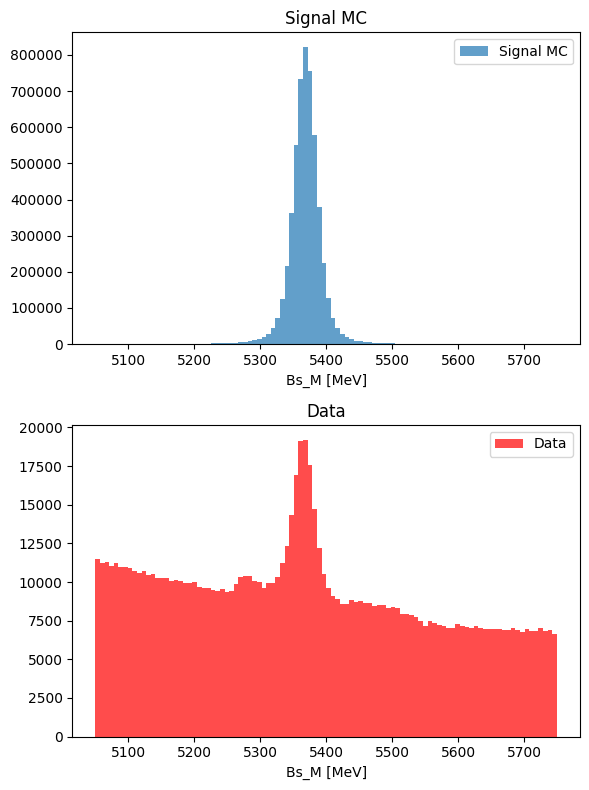

In [3]:
data_tr = uproot.open("./data/data.root:DecayTree")
data_tr.show()
sm = sig_tr.arrays( "Bs_M", library="np" )["Bs_M"]
dm = data_tr.arrays( "Bs_M", library="np" )["Bs_M"]

fig, ax = plt.subplots(2, 1, figsize=(6,8))
ax[0].hist(sm, bins=100, alpha=0.7, label='Signal MC')                                                                          
ax[0].set_xlabel('Bs_M [MeV]')                                                                                                             
ax[0].set_title('Signal MC')
ax[0].legend()

ax[1].hist(dm, bins=100, alpha=0.7, color='r', label='Data')
ax[1].set_xlabel('Bs_M [MeV]')
ax[1].set_title('Data')
ax[1].legend()

plt.tight_layout()

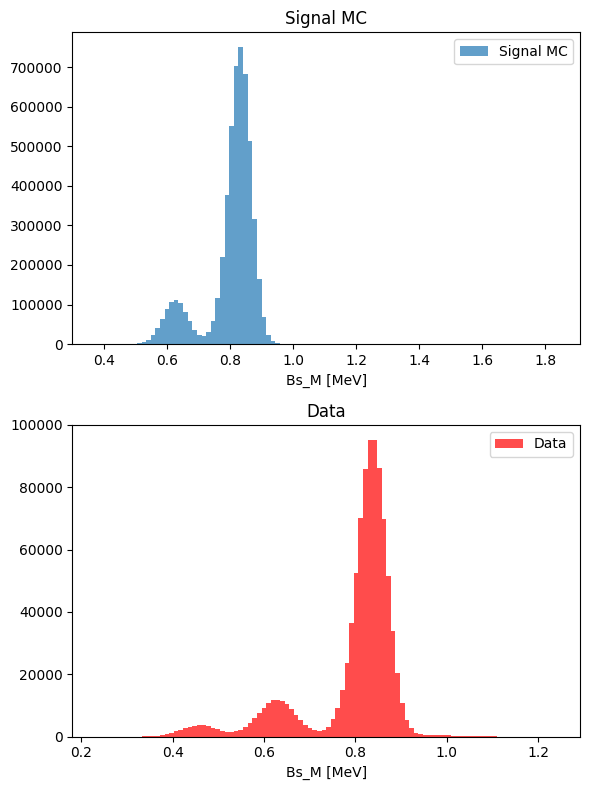

In [4]:
xxxsm = sig_tr.arrays( "Bs_ProductionVertex_X", library="np" )["Bs_ProductionVertex_X"]
xxxdm = data_tr.arrays( "Bs_ProductionVertex_X", library="np" )["Bs_ProductionVertex_X"]

fig, ax = plt.subplots(2, 1, figsize=(6,8))
ax[0].hist(xxxsm, bins=100, alpha=0.7, label='Signal MC')                                                                          
ax[0].set_xlabel('Bs_M [MeV]')                                                                                                             
ax[0].set_title('Signal MC')
ax[0].legend()

ax[1].hist(xxxdm, bins=100, alpha=0.7, color='r', label='Data')
ax[1].set_xlabel('Bs_M [MeV]')
ax[1].set_title('Data')
ax[1].legend()

plt.tight_layout()

In [5]:
sig_df = sig_tr.arrays( library='pd' )
bkg_df = data_tr.arrays( cut='Bs_M>5600', library='pd' )

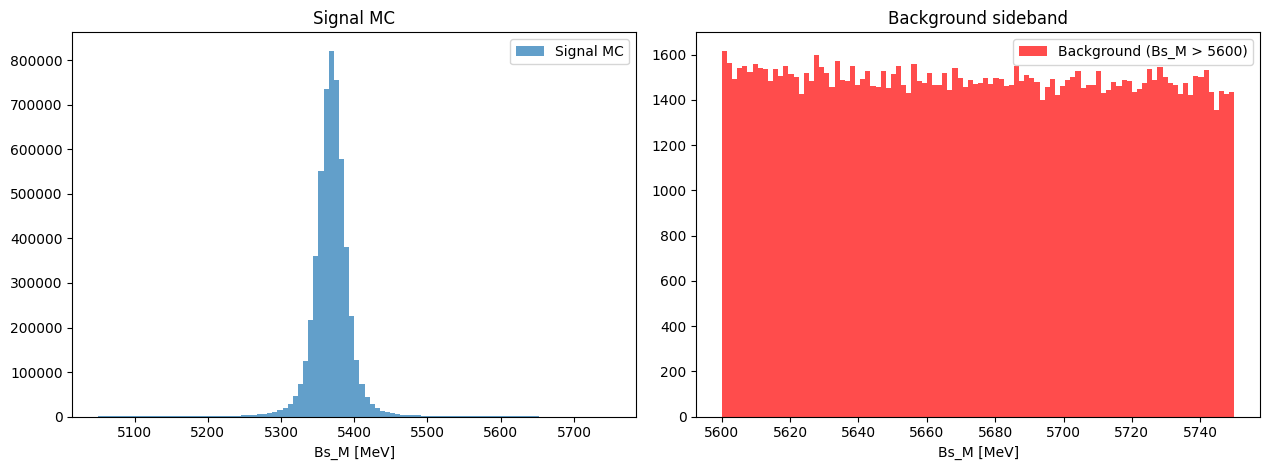

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12.8, 4.8))                                                                                                                                                                                                                                       


ax[0].hist(sig_df['Bs_M'], bins=100, alpha=0.7, label='Signal MC')                                                                          
ax[0].set_xlabel('Bs_M [MeV]')                                                                                                             
ax[0].set_title('Signal MC')
ax[0].legend()

ax[1].hist(bkg_df['Bs_M'], bins=100, alpha=0.7, color='r', label='Background (Bs_M > 5600)')
ax[1].set_xlabel('Bs_M [MeV]')
ax[1].set_title('Background sideband')
ax[1].legend()

plt.tight_layout()

In [7]:
# Quick sanity check: look for unphysical values
check_cols = [
    "Bs_DecayVertex_Chi2pDoF", "Bs_ProductionVertex_Chi2pDoF",
    "Bs_ImpactParameter_Chi2", "Bs_FlightDistance_Chi2",
    "Bs_FlightDistance", "Bs_DecayLength", "Bs_DecayTime",
    "Kst_DecayVertex_Chi2pDoF", "Kst_ImpactParameter_Chi2",
    "Kst_FlightDistance_Chi2", "Kst_FlightDistance",
]

print("=== Checking for unphysical values (negative Chi2, etc.) ===\n")
print(f"{'Feature':40s} {'min':>12s} {'max':>12s} {'#NaN':>8s} {'#neg':>8s}")
print("-" * 82)

for col in check_cols:
    for label, df in [("sig", sig_df), ("bkg", bkg_df)]:
        vals = df[col]
        n_nan = vals.isna().sum()
        n_neg = (vals < 0).sum()
        print(f"  {col:36s} [{label}]  {vals.min():12.3f} {vals.max():12.3f} {n_nan:8d} {n_neg:8d}")


=== Checking for unphysical values (negative Chi2, etc.) ===

Feature                                           min          max     #NaN     #neg
----------------------------------------------------------------------------------
  Bs_DecayVertex_Chi2pDoF              [sig]         0.001       12.000        0        0
  Bs_DecayVertex_Chi2pDoF              [bkg]         0.002       12.000        0        0
  Bs_ProductionVertex_Chi2pDoF         [sig]        -0.497        1.249        0       10
  Bs_ProductionVertex_Chi2pDoF         [bkg]         0.020        1.290        0        0
  Bs_ImpactParameter_Chi2              [sig]         0.000   206182.721        0        0
  Bs_ImpactParameter_Chi2              [bkg]         0.000     8915.527        0        0
  Bs_FlightDistance_Chi2               [sig]        80.835  4490905.215        0        0
  Bs_FlightDistance_Chi2               [bkg]        80.578  4950898.742        0        0
  Bs_FlightDistance                    [sig]      

In [8]:
# The 23 selected topological features (Bs + Kst only)
topo_features = [
    # Bs vertex / flight
    "Bs_ProductionVertex_Chi2pDoF",
    "Bs_DecayVertex_Chi2pDoF",
    "Bs_ImpactParameter",
    "Bs_ImpactParameter_Chi2",
    "Bs_FlightDistance",
    "Bs_FlightDistance_Chi2",
    "Bs_CosMomentumDecayAngle",
    "Bs_DistanceOfClosestApproach",
    "Bs_DecayTime",
    "Bs_DecayLength",
    # Bs kinematics
    "Bs_PT", "Bs_P",
    # Helicity angles
    "Bs_CosHelicityAngle_Kst",
    "Bs_CosHelicityAngle_Kstb",
    "Bs_HelcityAngle_Phi",
    # Kst topology / kinematics
    "Kst_P", "Kst_PT",
    "Kst_DecayVertex_Chi2pDoF",
    "Kst_ImpactParameter",
    "Kst_ImpactParameter_Chi2",
    "Kst_FlightDistance",
    "Kst_FlightDistance_Chi2",
    "Kst_CosMomentumDecayAngle",
]

# Label
sig_df['Class'] = 1
bkg_df['Class'] = 0

# Keep MC weight separately
sig_weights = sig_df['weight'].copy()

# Build clean dataframes with only the 23 features + Class
sig_clean = sig_df[topo_features + ['Class']].copy()
sig_clean['mc_weight'] = sig_weights.values

bkg_clean = bkg_df[topo_features + ['Class']].copy()
bkg_clean['mc_weight'] = 1.0

# Downsample signal to match background size (for balanced training)
n_bkg = len(bkg_clean)
sig_down = sig_clean.sample(n=n_bkg, random_state=42)
print(f"Downsampled signal: {len(sig_clean)} -> {len(sig_down)} (to match {n_bkg} background)")

# Combine
train_df = pd.concat([sig_down, bkg_clean], ignore_index=True)

# Train / Test / Val split (60% / 20% / 20%)
np.random.seed(42)
train_df['Sample'] = np.random.choice([0, 1, 2], p=[0.6, 0.2, 0.2], size=len(train_df))
# 0 = train, 1 = test, 2 = validation

# Prepare arrays
X_train = train_df[train_df['Sample']==0][topo_features].to_numpy()
X_test  = train_df[train_df['Sample']==1][topo_features].to_numpy()
X_val   = train_df[train_df['Sample']==2][topo_features].to_numpy()

y_train = train_df[train_df['Sample']==0]['Class'].to_numpy()
y_test  = train_df[train_df['Sample']==1]['Class'].to_numpy()
y_val   = train_df[train_df['Sample']==2]['Class'].to_numpy()

w_train = train_df[train_df['Sample']==0]['mc_weight'].to_numpy()
w_test  = train_df[train_df['Sample']==1]['mc_weight'].to_numpy()
w_val   = train_df[train_df['Sample']==2]['mc_weight'].to_numpy()

print(f"Features: {len(topo_features)}")
print(f"Train: {len(X_train)}  Test: {len(X_test)}  Val: {len(X_val)}")
print(f"Signal: {(train_df['Class']==1).sum()}  Background: {(train_df['Class']==0).sum()}")

Downsampled signal: 5357612 -> 149031 (to match 149031 background)
Features: 23
Train: 178494  Test: 59873  Val: 59695
Signal: 149031  Background: 149031


=== KS test ranking (23 topological features) ===
  Bs_CosMomentumDecayAngle                  KS=0.7800  p=0.00e+00
  Bs_FlightDistance_Chi2                    KS=0.6679  p=0.00e+00
  Bs_DecayLength                            KS=0.6409  p=0.00e+00
  Bs_FlightDistance                         KS=0.6343  p=0.00e+00
  Bs_ImpactParameter_Chi2                   KS=0.6215  p=0.00e+00
  Kst_ImpactParameter_Chi2                  KS=0.6120  p=0.00e+00
  Bs_ImpactParameter                        KS=0.5930  p=0.00e+00
  Bs_DecayTime                              KS=0.5915  p=0.00e+00
  Bs_PT                                     KS=0.5534  p=0.00e+00
  Kst_ImpactParameter                       KS=0.5434  p=0.00e+00
  Bs_DecayVertex_Chi2pDoF                   KS=0.4644  p=0.00e+00
  Bs_P                                      KS=0.3591  p=0.00e+00
  Kst_FlightDistance_Chi2                   KS=0.3545  p=0.00e+00
  Kst_PT                                    KS=0.3517  p=0.00e+00
  Kst_P                   

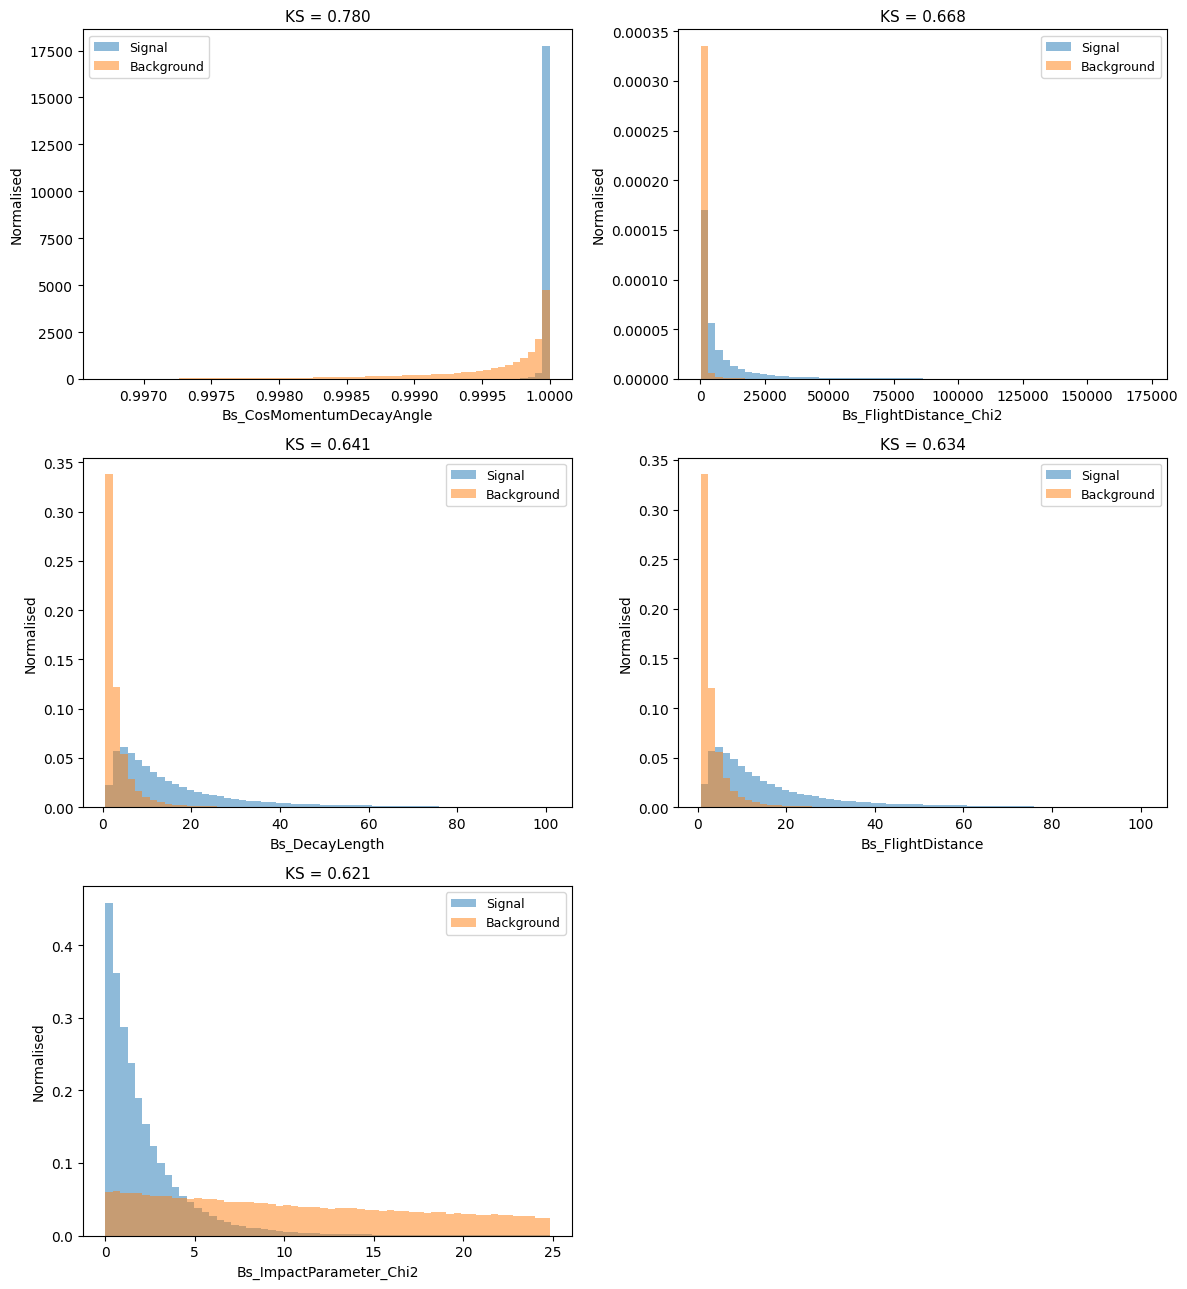

In [9]:

# KS test for the 23 topological features
ks_results = []
for feat in topo_features:
    s_vals = train_df[train_df['Class']==1][feat].dropna()
    b_vals = train_df[train_df['Class']==0][feat].dropna()
    stat, pval = ks_2samp(s_vals, b_vals)
    ks_results.append((feat, stat, pval))

ks_results.sort(key=lambda x: -x[1])

print("=== KS test ranking (23 topological features) ===")
for feat, stat, pval in ks_results:
    print(f"  {feat:40s}  KS={stat:.4f}  p={pval:.2e}")

# Plot top 5 features: signal vs background (3 rows x 2 cols, last subplot blank)
top5 = [feat for feat, _, _ in ks_results[:5]]

fig, axes = plt.subplots(3, 2, figsize=(12, 13))

for i, feat in enumerate(top5):
    row, col = divmod(i, 2)
    ax = axes[row][col]
    s_vals = train_df[train_df['Class']==1][feat].dropna()
    b_vals = train_df[train_df['Class']==0][feat].dropna()
    
    lo = min(s_vals.quantile(0.01), b_vals.quantile(0.01))
    hi = max(s_vals.quantile(0.99), b_vals.quantile(0.99))
    
    ax.hist(s_vals, bins=60, range=(lo, hi), alpha=0.5, density=True, label='Signal')
    ax.hist(b_vals, bins=60, range=(lo, hi), alpha=0.5, density=True, label='Background')
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('Normalised')
    ax.legend(fontsize=9)
    ax.set_title(f'KS = {ks_results[i][1]:.3f}', fontsize=11)

# hide the empty 6th subplot
axes[2][1].axis('off')

plt.tight_layout()
plt.show()

### BDT Training and Hyperparameter Optimisation

In [10]:
# --- Grid search: fix subsample=0.8, scan the rest ---
param_grid = {
    'n_estimators':  [100, 200, 300, 400],
    'max_depth':     [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
}

results = []

for ne, md, lr in itertools.product(param_grid['n_estimators'],
                                     param_grid['max_depth'],
                                     param_grid['learning_rate']):
    
    bdt_tmp = xgb.XGBClassifier(
        n_estimators=ne, max_depth=md, learning_rate=lr,
        subsample=0.8, eval_metric='logloss', random_state=42,
    )
    
    bdt_tmp.fit(X_train, y_train, sample_weight=w_train,
                eval_set=[(X_val, y_val)], verbose=False)
    
    train_auc = roc_auc_score(y_train, bdt_tmp.predict_proba(X_train)[:, 1], sample_weight=w_train)
    val_auc   = roc_auc_score(y_val,   bdt_tmp.predict_proba(X_val)[:, 1],   sample_weight=w_val)
    gap = train_auc - val_auc
    
    results.append({
        'n_estimators': ne, 'max_depth': md, 'learning_rate': lr,
        'train_auc': train_auc, 'val_auc': val_auc, 'gap': gap
    })
    
    print(f"  n_est={ne:4d}  depth={md}  lr={lr:.2f}  =>  train_AUC={train_auc:.5f}  val_AUC={val_auc:.5f}  gap={gap:.5f}")

results_df = pd.DataFrame(results).sort_values('val_auc', ascending=False)
print("\n=== Top 10 by val_AUC ===")
print(results_df.head(10).to_string(index=False))

  n_est= 100  depth=2  lr=0.01  =>  train_AUC=0.97095  val_AUC=0.97020  gap=0.00075
  n_est= 100  depth=2  lr=0.05  =>  train_AUC=0.98929  val_AUC=0.98873  gap=0.00056
  n_est= 100  depth=2  lr=0.10  =>  train_AUC=0.99250  val_AUC=0.99178  gap=0.00072
  n_est= 100  depth=3  lr=0.01  =>  train_AUC=0.97995  val_AUC=0.97918  gap=0.00077
  n_est= 100  depth=3  lr=0.05  =>  train_AUC=0.99193  val_AUC=0.99113  gap=0.00080
  n_est= 100  depth=3  lr=0.10  =>  train_AUC=0.99419  val_AUC=0.99340  gap=0.00079
  n_est= 100  depth=4  lr=0.01  =>  train_AUC=0.98523  val_AUC=0.98451  gap=0.00073
  n_est= 100  depth=4  lr=0.05  =>  train_AUC=0.99348  val_AUC=0.99250  gap=0.00099
  n_est= 100  depth=4  lr=0.10  =>  train_AUC=0.99526  val_AUC=0.99421  gap=0.00105
  n_est= 100  depth=5  lr=0.01  =>  train_AUC=0.98862  val_AUC=0.98771  gap=0.00091
  n_est= 100  depth=5  lr=0.05  =>  train_AUC=0.99463  val_AUC=0.99340  gap=0.00122
  n_est= 100  depth=5  lr=0.10  =>  train_AUC=0.99616  val_AUC=0.99473  gap=

In [11]:
# Filter: gap < 0.002, then pick best val_AUC
good = results_df[results_df['gap'] < 0.002].sort_values('val_auc', ascending=False)

print(f"Configurations with gap < 0.002: {len(good)} / {len(results_df)}\n")
print(good.to_string(index=False))

best = good.iloc[0]
print(f"\n=== Selected configuration ===")
print(f"  n_estimators:   {int(best['n_estimators'])}")
print(f"  max_depth:      {int(best['max_depth'])}")
print(f"  learning_rate:  {best['learning_rate']:.2f}")
print(f"  subsample:      0.8")
print(f"  val_AUC:        {best['val_auc']:.5f}")
print(f"  gap:            {best['gap']:.5f}")

Configurations with gap < 0.002: 43 / 48

 n_estimators  max_depth  learning_rate  train_auc  val_auc      gap
          300          4           0.10   0.997094 0.995334 0.001759
          400          3           0.10   0.996520 0.995224 0.001296
          300          5           0.05   0.996925 0.995177 0.001748
          400          4           0.05   0.996500 0.995109 0.001391
          300          3           0.10   0.996132 0.995043 0.001089
          200          4           0.10   0.996429 0.995035 0.001394
          300          4           0.05   0.996023 0.994839 0.001184
          200          5           0.05   0.996166 0.994759 0.001408
          100          5           0.10   0.996160 0.994734 0.001426
          200          3           0.10   0.995495 0.994600 0.000895
          400          3           0.05   0.995546 0.994594 0.000952
          400          2           0.10   0.995335 0.994442 0.000893
          200          4           0.05   0.995283 0.994272 0

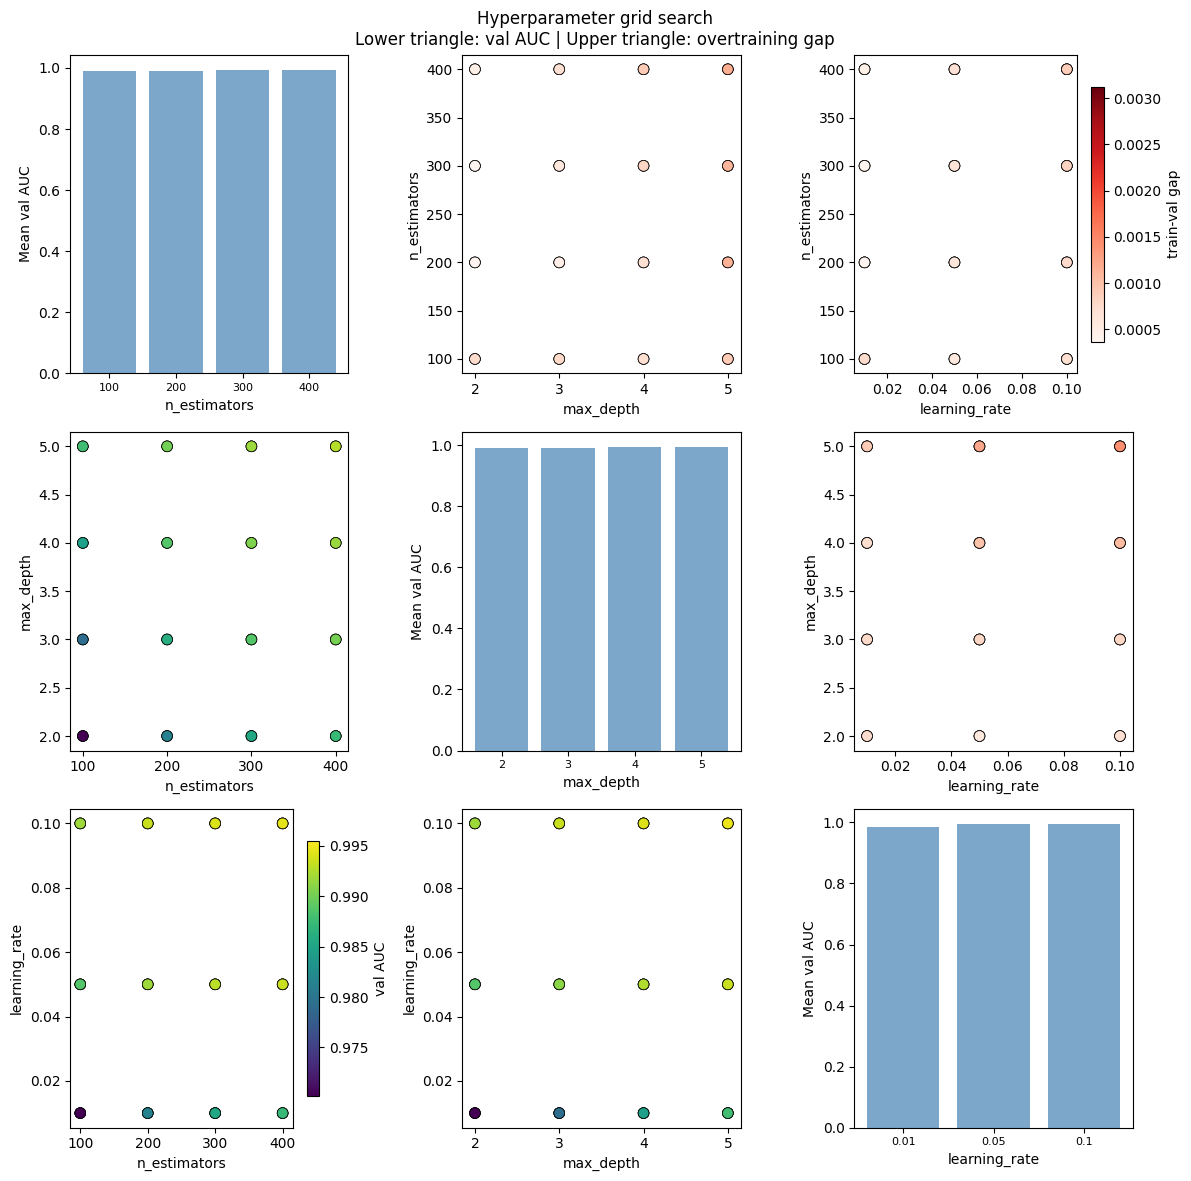

In [12]:
# --- Grid search corner plot: val_AUC as function of hyperparameters ---
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

param_names = ['n_estimators', 'max_depth', 'learning_rate']
param_labels = ['n_estimators', 'max_depth', 'learning_rate']

for i in range(3):
    for j in range(3):
        ax = axes[i][j]
        
        if i == j:
            # Diagonal: 1D marginal - average val_AUC for each value
            grouped = results_df.groupby(param_names[i])['val_auc'].mean()
            ax.bar(range(len(grouped)), grouped.values, color='steelblue', alpha=0.7)
            ax.set_xticks(range(len(grouped)))
            ax.set_xticklabels([f'{v}' for v in grouped.index], fontsize=8)
            ax.set_ylabel('Mean val AUC')
            ax.set_xlabel(param_labels[i])
        
        elif i > j:
            # Lower triangle: 2D scatter, color = val_AUC
            sc = ax.scatter(results_df[param_names[j]], results_df[param_names[i]], 
                           c=results_df['val_auc'], cmap='viridis', s=60, edgecolors='k', linewidth=0.5)
            ax.set_xlabel(param_labels[j])
            ax.set_ylabel(param_labels[i])
        
        else:
            # Upper triangle: 2D scatter, color = gap
            sc = ax.scatter(results_df[param_names[j]], results_df[param_names[i]],
                           c=results_df['gap'], cmap='Reds', s=60, edgecolors='k', linewidth=0.5)
            ax.set_xlabel(param_labels[j])
            ax.set_ylabel(param_labels[i])

# Add colorbars
fig.colorbar(plt.cm.ScalarMappable(cmap='viridis', 
             norm=plt.Normalize(results_df['val_auc'].min(), results_df['val_auc'].max())),
             ax=axes[2, 0], label='val AUC', shrink=0.8)
fig.colorbar(plt.cm.ScalarMappable(cmap='Reds',
             norm=plt.Normalize(results_df['gap'].min(), results_df['gap'].max())),
             ax=axes[0, 2], label='train-val gap', shrink=0.8)

fig.suptitle('Hyperparameter grid search\nLower triangle: val AUC | Upper triangle: overtraining gap', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
# --- Train final BDT with selected hyperparameters ---
print(f"Training final BDT: n_est={int(best['n_estimators'])}, depth={int(best['max_depth'])}, "
      f"lr={best['learning_rate']:.2f}, subsample=0.8")

bdt = xgb.XGBClassifier(
    n_estimators=int(best['n_estimators']),
    max_depth=int(best['max_depth']),
    learning_rate=best['learning_rate'],
    subsample=0.8,
    eval_metric='logloss',
    random_state=42,
)

bdt.fit(X_train, y_train, sample_weight=w_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False)

print("Final BDT trained.")

Training final BDT: n_est=300, depth=4, lr=0.10, subsample=0.8
Final BDT trained.


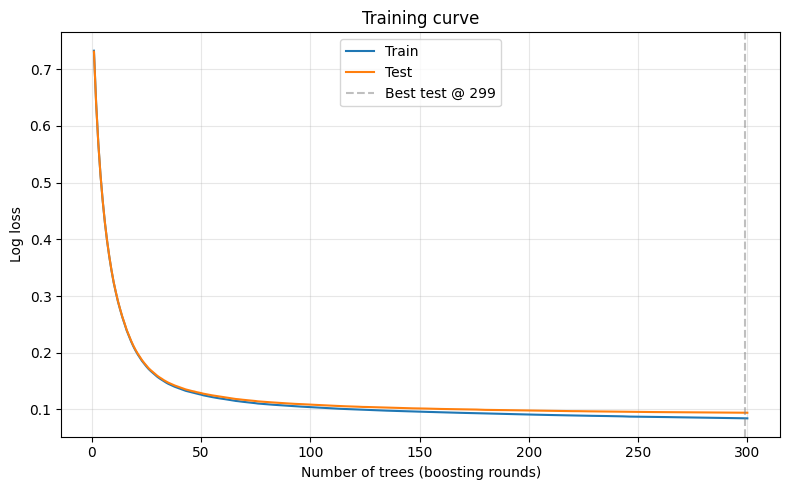

Train loss (final): 0.08440
Test loss  (final): 0.09428
Test loss  (best):  0.09428 at round 299


In [14]:
# --- Learning curve: train vs test loss ---
results = bdt.evals_result()
train_loss = results['validation_0']['logloss']
test_loss  = results['validation_1']['logloss']
epochs = range(1, len(train_loss) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, train_loss, label='Train', linewidth=1.5)
ax.plot(epochs, test_loss, label='Test', linewidth=1.5)
ax.set_xlabel('Number of trees (boosting rounds)')
ax.set_ylabel('Log loss')
ax.set_title('Training curve')
ax.legend()
ax.grid(True, alpha=0.3)

# Check for overtraining: if test loss starts increasing while train keeps decreasing
min_test_idx = np.argmin(test_loss)
ax.axvline(min_test_idx + 1, color='grey', linestyle='--', alpha=0.5, label=f'Best test @ {min_test_idx+1}')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Train loss (final): {train_loss[-1]:.5f}")
print(f"Test loss  (final): {test_loss[-1]:.5f}")
print(f"Test loss  (best):  {min(test_loss):.5f} at round {min_test_idx+1}")

### Overtraining Check

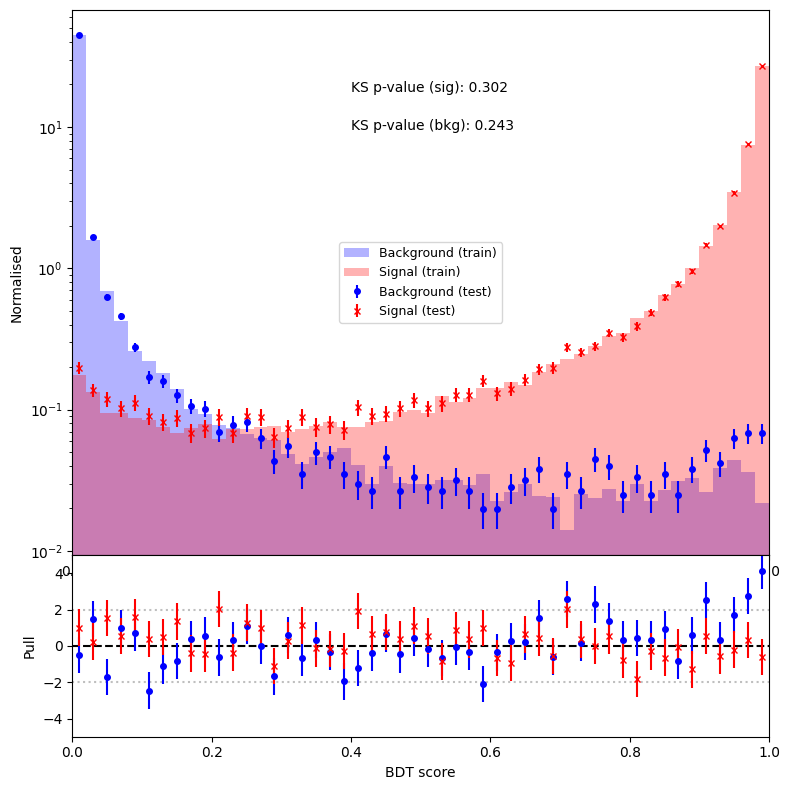


KS test signal:     stat=0.0065, p=0.3016
KS test background: stat=0.0068, p=0.2426
(p > 0.05 => no evidence of overtraining)


In [15]:
from scipy.stats import ks_2samp

# Predict on train and test
y_train_pred = bdt.predict_proba(X_train)[:, 1]
y_test_pred  = bdt.predict_proba(X_test)[:, 1]

# Split by class
y_train_pred_sig = y_train_pred[y_train == 1]
y_train_pred_bkg = y_train_pred[y_train == 0]
y_test_pred_sig  = y_test_pred[y_test == 1]
y_test_pred_bkg  = y_test_pred[y_test == 0]

# KS tests: compare train vs test for each class
ks_sig = ks_2samp(y_train_pred_sig, y_test_pred_sig)
ks_bkg = ks_2samp(y_train_pred_bkg, y_test_pred_bkg)

# --- Plot ---
fig, ax = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': (3, 1), 'hspace': 0})

bins = 50
rng = (0, 1)

# Upper panel: overlaid distributions
# Train: filled histograms
ax[0].hist(y_train_pred_bkg, bins=bins, range=rng, alpha=0.3, color='b', density=True, label='Background (train)')
ax[0].hist(y_train_pred_sig, bins=bins, range=rng, alpha=0.3, color='r', density=True, label='Signal (train)')

# Test: error bar points
nh_bkg, xe = np.histogram(y_test_pred_bkg, bins=bins, range=rng)
dh_bkg, _  = np.histogram(y_test_pred_bkg, bins=bins, range=rng, density=True)
de_bkg = dh_bkg * (nh_bkg**0.5 / np.maximum(nh_bkg, 1))

nh_sig, _  = np.histogram(y_test_pred_sig, bins=bins, range=rng)
dh_sig, _  = np.histogram(y_test_pred_sig, bins=bins, range=rng, density=True)
de_sig = dh_sig * (nh_sig**0.5 / np.maximum(nh_sig, 1))

cx = 0.5 * (xe[1:] + xe[:-1])
ax[0].errorbar(cx, dh_bkg, de_bkg, fmt='bo', markersize=4, label='Background (test)')
ax[0].errorbar(cx, dh_sig, de_sig, fmt='rx', markersize=4, label='Signal (test)')

ax[0].set_ylabel('Normalised')
ax[0].set_yscale('log')
ax[0].legend(fontsize=9)
ax[0].text(0.4, 0.85, f'KS p-value (sig): {ks_sig.pvalue:.3f}', transform=ax[0].transAxes, fontsize=10)
ax[0].text(0.4, 0.78, f'KS p-value (bkg): {ks_bkg.pvalue:.3f}', transform=ax[0].transAxes, fontsize=10)
ax[0].set_xlim(0, 1)

# Lower panel: pull = (test - train) / error
# Train histograms for pull calculation
nh_train_bkg, _ = np.histogram(y_train_pred_bkg, bins=bins, range=rng)
dh_train_bkg, _ = np.histogram(y_train_pred_bkg, bins=bins, range=rng, density=True)
de_train_bkg = dh_train_bkg * (nh_train_bkg**0.5 / np.maximum(nh_train_bkg, 1))

nh_train_sig, _ = np.histogram(y_train_pred_sig, bins=bins, range=rng)
dh_train_sig, _ = np.histogram(y_train_pred_sig, bins=bins, range=rng, density=True)
de_train_sig = dh_train_sig * (nh_train_sig**0.5 / np.maximum(nh_train_sig, 1))

# Pull
err_bkg = np.sqrt(de_bkg**2 + de_train_bkg**2)
pull_bkg = np.where(err_bkg > 0, (dh_bkg - dh_train_bkg) / err_bkg, 0)

err_sig = np.sqrt(de_sig**2 + de_train_sig**2)
pull_sig = np.where(err_sig > 0, (dh_sig - dh_train_sig) / err_sig, 0)

ax[1].axhline(0, color='k', linestyle='--')
ax[1].axhline(2, color='grey', linestyle=':', alpha=0.5)
ax[1].axhline(-2, color='grey', linestyle=':', alpha=0.5)
ax[1].errorbar(cx, pull_bkg, np.ones_like(pull_bkg), fmt='bo', markersize=4)
ax[1].errorbar(cx, pull_sig, np.ones_like(pull_sig), fmt='rx', markersize=4)
ax[1].set_xlabel('BDT score')
ax[1].set_ylabel('Pull')
ax[1].set_ylim(-5, 5)
ax[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

print(f"\nKS test signal:     stat={ks_sig.statistic:.4f}, p={ks_sig.pvalue:.4f}")
print(f"KS test background: stat={ks_bkg.statistic:.4f}, p={ks_bkg.pvalue:.4f}")
print("(p > 0.05 => no evidence of overtraining)")

### BDT Cut Optimisation via $S/\sqrt{S+B}$

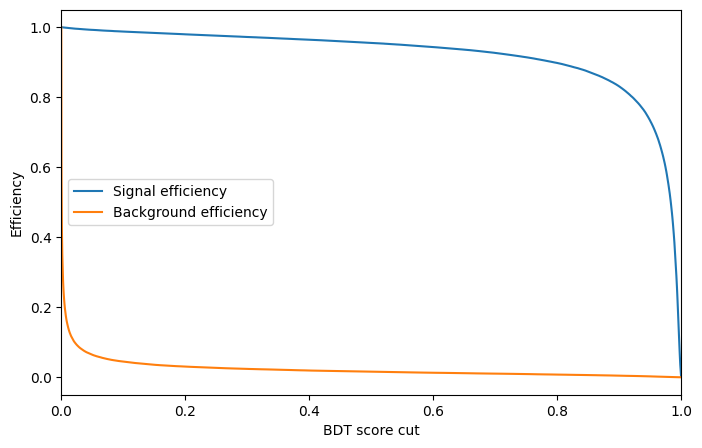

In [16]:
# --- Step 1: Compute BDT efficiency curves from labelled training sample ---
X_all = train_df[topo_features].to_numpy()
y_all = train_df["Class"].to_numpy()
bdt_scores_all = bdt.predict_proba(X_all)[:, 1]

# Sort by BDT score
sorted_idx = np.argsort(bdt_scores_all)
sorted_scores = bdt_scores_all[sorted_idx]
sorted_labels = y_all[sorted_idx]

n_sig = (sorted_labels == 1).sum()
n_bkg = (sorted_labels == 0).sum()

sig_rej = np.cumsum(sorted_labels == 1) / n_sig
bkg_rej = np.cumsum(sorted_labels == 0) / n_bkg

sig_eff = 1 - sig_rej
bkg_eff = 1 - bkg_rej

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sorted_scores, sig_eff, label="Signal efficiency")
ax.plot(sorted_scores, bkg_eff, label="Background efficiency")
ax.set_xlabel("BDT score cut")
ax.set_ylabel("Efficiency")
ax.legend()
ax.set_xlim(0, 1)
plt.show()

Ns_init = 61815 +/- 454
Nb_init = 877519 +/- 1011
mu = 5365.50 +/- 0.01 MeV
sigma = 16.92 +/- 0.14 MeV


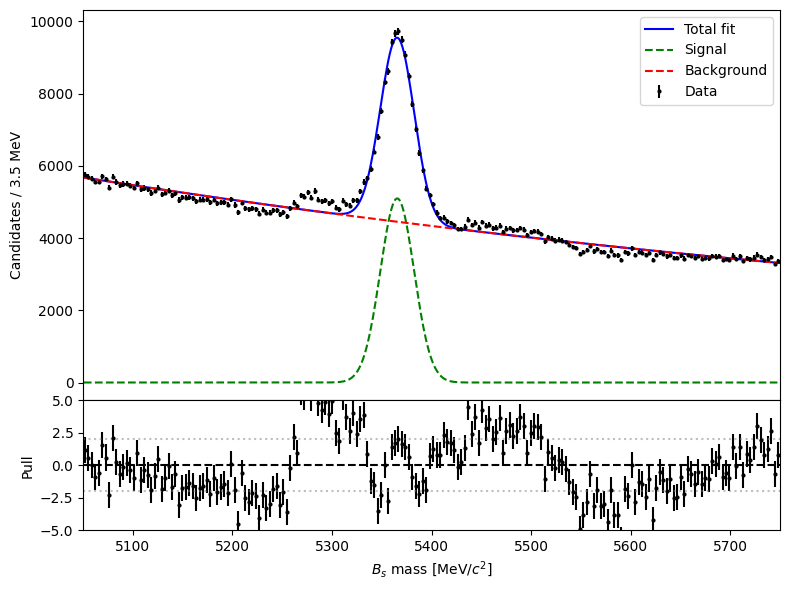

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1174 (χ²/ndof = 6.0)       │             Nfcn = 2303              │
│ EDM = 36.2 (Goal: 0.0002)        │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Ns   │  61.8e3   │   0.5e3   │            │            │    0    │ 939428  │       │
│ 1 │ Nb   │  877.5e3  │   1.0e3   │            │            │    0    │ 939428  │       │
│ 2 │ mu   │5.365501e3 │0.000015e3 │            │            │  5340   │  5400   │       │
│ 3 │ sg   │   16.92   │   0.14    │            │            │    1    │   50    │       │
│ 4 │ lb   │771.902e-6 │ 0.025e-6  │            │            │    0    │   0.1   │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────────────────────────────────────────────────────────┐
│    │            Ns            Nb            mu            sg            lb │
├────┼───────────────────────────────────────────────────────────────────────┤
│ Ns │      2.06e+05       -0.14e6             0        32.563  2.3276834e-9 │
│ Nb │       -0.14e6      1.02e+06             0       -32.535 -2.3287864e-9 │
│ mu │             0             0      0.000223             0             0 │
│ sg │        32.563       -32.535             0        0.0202    1.7642e-12 │
│ lb │  2.3276834e-9 -2.3287864e-9             0    1.7642e-12      6.44e-16 │
└────┴───────────────────────────────────────────────────────────────────────┘

In [17]:
# --- Step 2: Initial mass fit on raw data (Gaussian + Exponential) ---

mrange = (5050, 5750)

def bkgcdf(x, lb):
    return truncexpon.cdf(x, mrange[0], mrange[1], mrange[0], 1/lb)

def sigcdf(x, mu, sg):
    return truncnorm.cdf(x, mrange[0], mrange[1], mu, sg)

def totcdf(x, Ns, Nb, mu, sg, lb):
    return Ns * sigcdf(x, mu, sg) + Nb * bkgcdf(x, lb)

# Histogram the raw data mass
mass = dm[(dm > mrange[0]) & (dm < mrange[1])]
nbins = 200
nh, xe = np.histogram(mass, bins=nbins, range=mrange)

# Extended binned likelihood fit
n2ll = cost.ExtendedBinnedNLL(nh, xe, totcdf)

mi = Minuit(n2ll, Ns=50000, Nb=len(mass)-50000, mu=5367, sg=20, lb=0.002)
mi.limits["Ns", "Nb"] = (0, len(mass))
mi.limits["mu"] = (5340, 5400)
mi.limits["sg"] = (1, 50)
mi.limits["lb"] = (0, 0.1)

mi.migrad()
mi.hesse()

Ns_init = mi.values["Ns"]
Nb_init = mi.values["Nb"]
print(f'Ns_init = {Ns_init:.0f} +/- {mi.errors["Ns"]:.0f}')
print(f'Nb_init = {Nb_init:.0f} +/- {mi.errors["Nb"]:.0f}')
print(f'mu = {mi.values["mu"]:.2f} +/- {mi.errors["mu"]:.2f} MeV')
print(f'sigma = {mi.values["sg"]:.2f} +/- {mi.errors["sg"]:.2f} MeV')

# --- Plot the fit ---
fig, ax = plt.subplots(2, 1, figsize=(8, 6),
                       gridspec_kw={"height_ratios": (3, 1), "hspace": 0})

cx = 0.5 * (xe[1:] + xe[:-1])
bw = xe[1] - xe[0]

ax[0].errorbar(cx, nh, np.sqrt(nh), fmt="k.", markersize=4, label="Data")

# Fit curves (only in fit range)
xf = np.linspace(mrange[0], mrange[1], 500)
tot_cdf_v = totcdf(xf, *mi.values)
sig_cdf_v = mi.values["Ns"] * sigcdf(xf, mi.values["mu"], mi.values["sg"])
bkg_cdf_v = mi.values["Nb"] * bkgcdf(xf, mi.values["lb"])

dx = xf[1] - xf[0]
tot_pdf = np.diff(tot_cdf_v) / dx * bw
sig_pdf = np.diff(sig_cdf_v) / dx * bw
bkg_pdf = np.diff(bkg_cdf_v) / dx * bw
xm = 0.5 * (xf[1:] + xf[:-1])

ax[0].plot(xm, tot_pdf, "b-", label="Total fit")
ax[0].plot(xm, sig_pdf, "g--", label="Signal")
ax[0].plot(xm, bkg_pdf, "r--", label="Background")
ax[0].set_ylabel(f"Candidates / {bw:.1f} MeV")
ax[0].legend()
ax[0].set_xlim(mrange)
ax[0].tick_params(labelbottom=False)

# Pull (only in fit range)
expected = np.diff(totcdf(xe, *mi.values))
pull = (nh - expected) / np.sqrt(np.maximum(expected, 1))
ax[1].errorbar(cx, pull, 1, fmt="k.", markersize=4)
ax[1].axhline(0, color="k", linestyle="--")
ax[1].axhline(2, color="grey", linestyle=":", alpha=0.5)
ax[1].axhline(-2, color="grey", linestyle=":", alpha=0.5)
ax[1].set_xlabel("$B_s$ mass [MeV/$c^2$]")
ax[1].set_ylabel("Pull")
ax[1].set_ylim(-5, 5)
ax[1].set_xlim(mrange)

plt.tight_layout()
plt.show()
mi

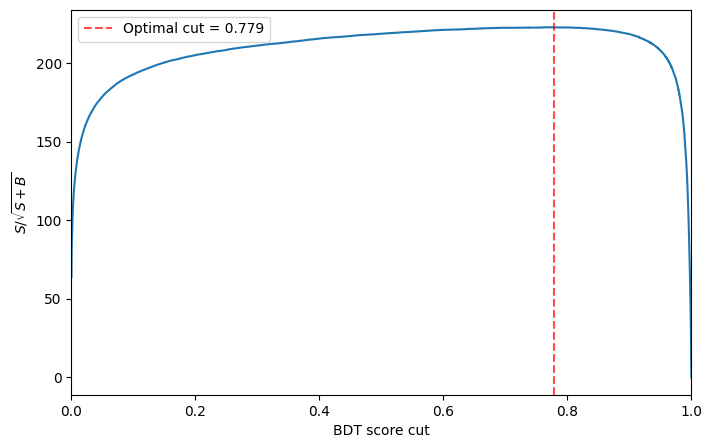

Optimal BDT cut: 0.7785
  S = 55963, B = 7101, S/sqrt(S+B) = 222.8


In [18]:
# --- Step 3: FOM = S/sqrt(S+B) using efficiency scaling ---
sig_pred = Ns_init * sig_eff
bkg_pred = Nb_init * bkg_eff

with np.errstate(divide="ignore", invalid="ignore"):
    fom1 = np.where(sig_pred + bkg_pred > 0,
                    sig_pred / np.sqrt(sig_pred + bkg_pred), 0)

best_cut = sorted_scores[np.argmax(fom1)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sorted_scores, fom1)
ax.axvline(best_cut, color="r", linestyle="--", alpha=0.7,
           label=f"Optimal cut = {best_cut:.3f}")
ax.set_xlabel("BDT score cut")
ax.set_ylabel(r"$S/\sqrt{S+B}$")
ax.legend()
ax.set_xlim(0, 1)
plt.show()

idx = np.argmax(fom1)
print(f"Optimal BDT cut: {best_cut:.4f}")
print(f"  S = {sig_pred[idx]:.0f}, B = {bkg_pred[idx]:.0f}, S/sqrt(S+B) = {fom1[idx]:.1f}")

### Apply BDT Selection

BDT cut: 0.7785
Before: 939429  After: 154193  Data retention: 0.164
Signal efficiency:     0.905 (90.5%)
Background efficiency: 0.008 (0.8%)
Background rejection:  0.992 (99.2%)
Estimated S = 55963, B = 7101, S/sqrt(S+B) = 222.8


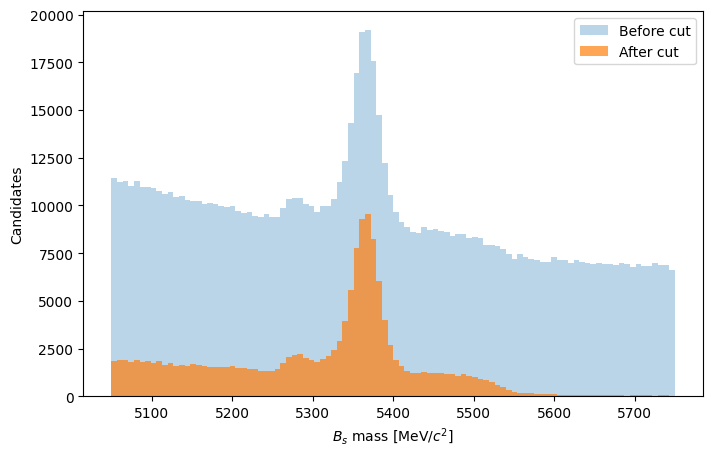

In [19]:
# --- Apply optimal BDT cut to full data ---
data_df = data_tr.arrays(library="pd")
data_df["bdt_score"] = bdt.predict_proba(data_df[topo_features].to_numpy())[:, 1]

sel_df = data_df[data_df["bdt_score"] >= best_cut].copy()

# Signal and background efficiency at optimal cut
idx = np.argmax(fom1)
sig_eff_opt = sig_eff[idx]
bkg_eff_opt = bkg_eff[idx]

print(f"BDT cut: {best_cut:.4f}")
print(f"Before: {len(data_df)}  After: {len(sel_df)}  Data retention: {len(sel_df)/len(data_df):.3f}")
print(f"Signal efficiency:     {sig_eff_opt:.3f} ({sig_eff_opt*100:.1f}%)")
print(f"Background efficiency: {bkg_eff_opt:.3f} ({bkg_eff_opt*100:.1f}%)")
print(f"Background rejection:  {1 - bkg_eff_opt:.3f} ({(1-bkg_eff_opt)*100:.1f}%)")
print(f"Estimated S = {sig_pred[idx]:.0f}, B = {bkg_pred[idx]:.0f}, S/sqrt(S+B) = {fom1[idx]:.1f}")

# Mass distribution before and after
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(data_df["Bs_M"], bins=100, range=(5050, 5750), alpha=0.3, label="Before cut")
ax.hist(sel_df["Bs_M"], bins=100, range=(5050, 5750), alpha=0.7, label="After cut")
ax.set_xlabel("$B_s$ mass [MeV/$c^2$]")
ax.set_ylabel("Candidates")
ax.legend()
plt.show()

### Reducing Other Backgrounds with PID Cuts

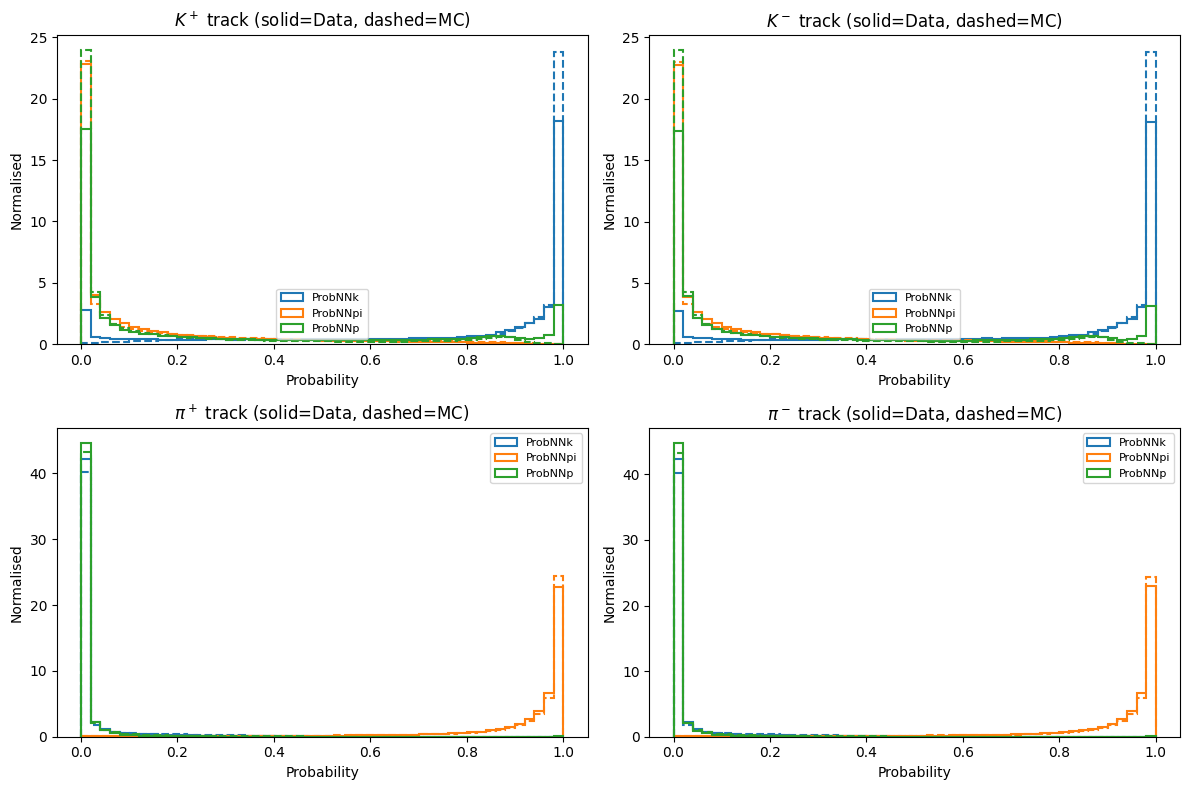

In [20]:
# --- PID distributions: Signal MC (dashed) vs Data (solid), grouped by track ---
pid_vars_by_track = {
    r"$K^+$": ["Kp_ProbNNk", "Kp_ProbNNpi", "Kp_ProbNNp"],
    r"$K^-$": ["Km_ProbNNk", "Km_ProbNNpi", "Km_ProbNNp"],
    r"$\pi^+$": ["pip_ProbNNk", "pip_ProbNNpi", "pip_ProbNNp"],
    r"$\pi^-$": ["pim_ProbNNk", "pim_ProbNNpi", "pim_ProbNNp"],
}

all_pid = [v for vs in pid_vars_by_track.values() for v in vs]
sig_pid_all = sig_tr.arrays(all_pid, library="pd")

pid_labels = ["ProbNNk", "ProbNNpi", "ProbNNp"]
pid_colors = ["C0", "C1", "C2"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (track, vars_list) in zip(axes.flatten(), pid_vars_by_track.items()):
    for var, label, color in zip(vars_list, pid_labels, pid_colors):
        # MC: dashed
        ax.hist(sig_pid_all[var], bins=50, range=(0, 1), density=True,
                histtype="step", linestyle="--", color=color, linewidth=1.5)
        # Data: solid
        ax.hist(sel_df[var], bins=50, range=(0, 1), density=True,
                histtype="step", linestyle="-", color=color, linewidth=1.5,
                label=label)
    ax.set_xlabel("Probability")
    ax.set_ylabel("Normalised")
    ax.set_title(f"{track} track (solid=Data, dashed=MC)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

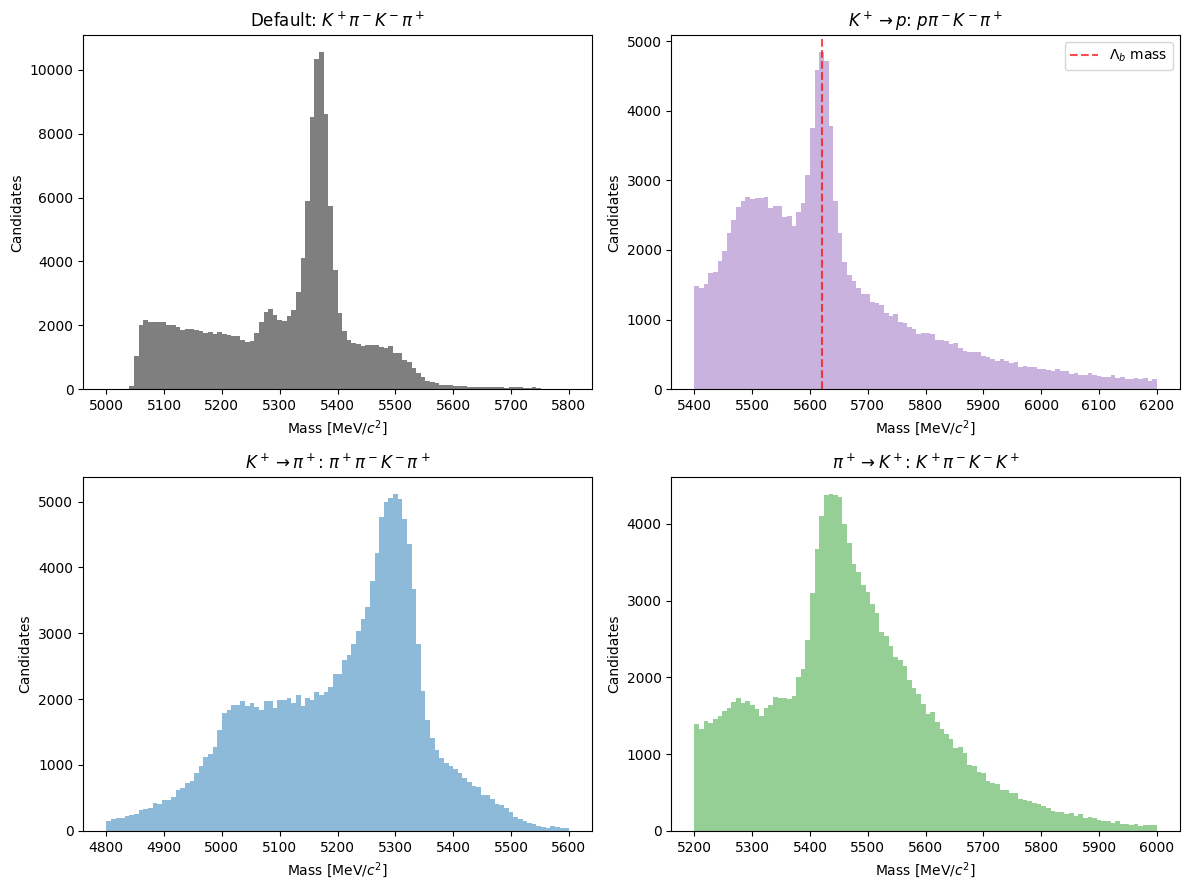

In [21]:
# --- Identify peaking backgrounds by swapping mass hypotheses ---

K_mass  = 493.677   # MeV
pi_mass = 139.570   # MeV
p_mass  = 938.272   # MeV

def make_p4(df, prefix, mass):
    return vector.arr({
        "px": df[f"{prefix}_PX"].values,
        "py": df[f"{prefix}_PY"].values,
        "pz": df[f"{prefix}_PZ"].values,
        "mass": np.full(len(df), mass)
    })

Kp  = make_p4(sel_df, "Kp",  K_mass)
pim = make_p4(sel_df, "pim", pi_mass)
Km  = make_p4(sel_df, "Km",  K_mass)
pip = make_p4(sel_df, "pip", pi_mass)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (a) Default: K+pi-K-pi+
M_default = (Kp + pim + Km + pip).m
axes[0,0].hist(M_default, bins=100, range=(5000, 5800), color="k", alpha=0.5)
axes[0,0].set_title(r"Default: $K^+\pi^-K^-\pi^+$")

# (b) K+ -> p: test Lb -> p pi- K- pi+
Kp_as_p = make_p4(sel_df, "Kp", p_mass)
M_Kp_p = (Kp_as_p + pim + Km + pip).m
axes[0,1].hist(M_Kp_p, bins=100, range=(5400, 6200), color="C4", alpha=0.5)
axes[0,1].set_title(r"$K^+\to p$: $p\pi^-K^-\pi^+$")
axes[0,1].axvline(5620, color="r", linestyle="--", alpha=0.7, label=r"$\Lambda_b$ mass")
axes[0,1].legend()

# (c) K+ -> pi+: test B0 -> pi+pi-K-pi+
Kp_as_pi = make_p4(sel_df, "Kp", pi_mass)
M_Kp_pi = (Kp_as_pi + pim + Km + pip).m
axes[1,0].hist(M_Kp_pi, bins=100, range=(4800, 5600), color="C0", alpha=0.5)
axes[1,0].set_title(r"$K^+\to \pi^+$: $\pi^+\pi^-K^-\pi^+$")

# (d) pi+ -> K+: test Bs -> K+pi-K-K+
pip_as_K = make_p4(sel_df, "pip", K_mass)
M_pip_K = (Kp + pim + Km + pip_as_K).m
axes[1,1].hist(M_pip_K, bins=100, range=(5200, 6000), color="C2", alpha=0.5)
axes[1,1].set_title(r"$\pi^+\to K^+$: $K^+\pi^-K^-K^+$")

for ax in axes.flatten():
    ax.set_xlabel("Mass [MeV/$c^2$]")
    ax.set_ylabel("Candidates")

plt.tight_layout()
plt.show()

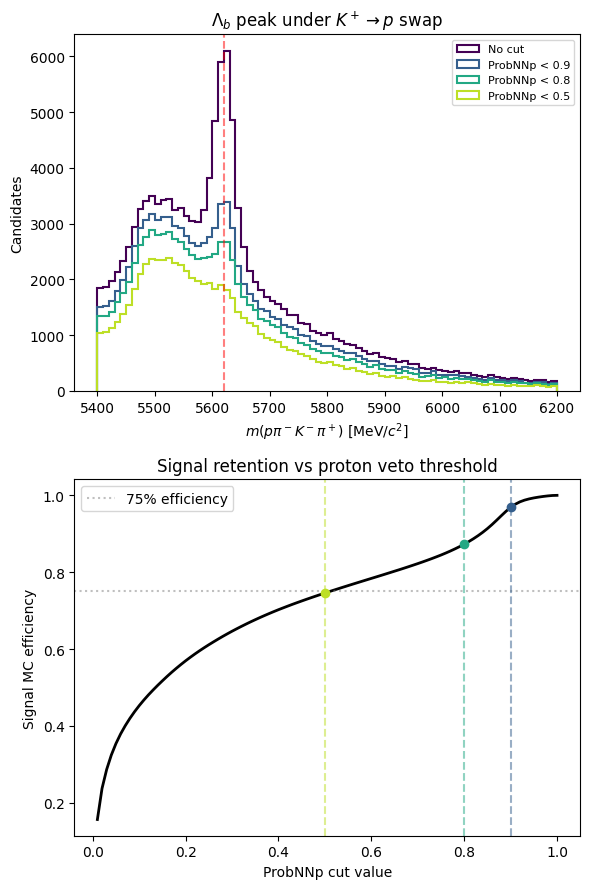

In [22]:
# --- Optimize proton veto: Lb peak vs ProbNNp cut ---
# Reuse 4-vectors from mass swap cell
M_Kp_p = (Kp_as_p + pim + Km + pip).m  # K+ -> p hypothesis

cuts = [1.0, 0.9, 0.8, 0.5]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(cuts)))

fig, axes = plt.subplots(2, 1, figsize=(6, 9))

# Left: Lb mass swap for different ProbNNp cuts
for cut_val, col in zip(cuts, colors):
    if cut_val >= 1.0:
        mask = np.ones(len(sel_df), dtype=bool)
        label = "No cut"
    else:
        mask = (sel_df["Kp_ProbNNp"].values < cut_val) & (sel_df["Km_ProbNNp"].values < cut_val)
        label = f"ProbNNp < {cut_val}"
    axes[0].hist(M_Kp_p[mask], bins=80, range=(5400, 6200),
                 histtype="step", linewidth=1.5, color=col, label=label)

axes[0].axvline(5620, color="r", linestyle="--", alpha=0.5)
axes[0].set_xlabel(r"$m(p\pi^-K^-\pi^+)$ [MeV/$c^2$]")
axes[0].set_ylabel("Candidates")
axes[0].set_title(r"$\Lambda_b$ peak under $K^+\to p$ swap")
axes[0].legend(fontsize=8)

# Right: Signal MC efficiency vs cut
mc_Kp_p = sig_tr.arrays(["Kp_ProbNNp", "Km_ProbNNp"], library="pd")
scan_cuts = np.linspace(0.01, 1.0, 100)
mc_effs = [(( mc_Kp_p["Kp_ProbNNp"] < c) & (mc_Kp_p["Km_ProbNNp"] < c)).mean() for c in scan_cuts]

axes[1].plot(scan_cuts, mc_effs, "k-", linewidth=2)
axes[1].set_xlabel("ProbNNp cut value")
axes[1].set_ylabel("Signal MC efficiency")
axes[1].set_title("Signal retention vs proton veto threshold")
axes[1].axhline(0.75, color="grey", linestyle=":", alpha=0.5, label="75% efficiency")

# Mark the chosen cuts
for cut_val, col in zip(cuts[1:], colors[1:]):
    eff = ((mc_Kp_p["Kp_ProbNNp"] < cut_val) & (mc_Kp_p["Km_ProbNNp"] < cut_val)).mean()
    axes[1].axvline(cut_val, color=col, linestyle="--", alpha=0.5)
    axes[1].plot(cut_val, eff, "o", color=col, markersize=6)

axes[1].legend()

plt.tight_layout()
plt.show()

Proton veto ProbNNp < 0.5:
  Data: 154193 -> 83292 (0.540)
  Signal MC efficiency: 0.746


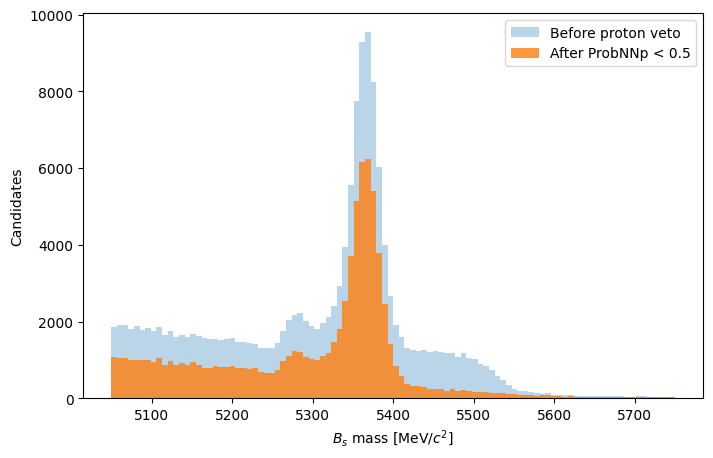

In [23]:
# --- Test proton veto at 0.5 (without modifying sel_df) ---
test_cut = 0.5
mask_test = (sel_df["Kp_ProbNNp"] < test_cut) & (sel_df["Km_ProbNNp"] < test_cut)
test_df = sel_df[mask_test]

# Signal MC efficiency
mc_pv = sig_tr.arrays(["Kp_ProbNNp", "Km_ProbNNp"], library="pd")
mc_eff = ((mc_pv["Kp_ProbNNp"] < test_cut) & (mc_pv["Km_ProbNNp"] < test_cut)).mean()

print(f"Proton veto ProbNNp < {test_cut}:")
print(f"  Data: {len(sel_df)} -> {len(test_df)} ({len(test_df)/len(sel_df):.3f})")
print(f"  Signal MC efficiency: {mc_eff:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(sel_df["Bs_M"], bins=100, range=(5050, 5750),
        alpha=0.3, label="Before proton veto")
ax.hist(test_df["Bs_M"], bins=100, range=(5050, 5750),
        alpha=0.8, label=f"After ProbNNp < {test_cut}")
ax.set_xlabel("$B_s$ mass [MeV/$c^2$]")
ax.set_ylabel("Candidates")
ax.legend()
plt.show()

### $B$ Candidate Mass Fit

In [24]:
# --- Data mass fit (CB+Gauss + B0 + Bernstein + ARGUS*Gauss) ---
mrange = (5050., 5750.)
nbins = 300
m0_argus_init = 5232.

final_df = sel_df[(sel_df["Kp_ProbNNp"] < 0.5) & (sel_df["Km_ProbNNp"] < 0.5)].copy()
final_mass = final_df["Bs_M"].values.astype(np.float64)
final_mass = final_mass[(final_mass > mrange[0]) & (final_mass < mrange[1])]
print(f"Events in fit range: {len(final_mass)}")

def sig_cdf_free(x, mu, fcb, sg1, sg2, beta, m):
    cbn = np.diff(crystalball.cdf(np.array(mrange), beta, m, mu, sg1))
    cbd = crystalball.cdf(mrange[0], beta, m, mu, sg1)
    cb = (crystalball.cdf(x, beta, m, mu, sg1) - cbd) / cbn
    gs = truncnorm.cdf(x, mrange[0], mrange[1], mu, sg2)
    return fcb * cb + (1 - fcb) * gs

def bkg_cdf_bern(x, b0, b1, b2, b3):
    beta_coeffs = np.array([b0, b1, b2, b3], dtype=np.float64)
    num = bernstein.integral(np.asarray(x, dtype=np.float64), beta_coeffs,
                             np.float64(mrange[0]), np.float64(mrange[1]))
    den = np.diff(bernstein.integral(np.array(mrange, dtype=np.float64), beta_coeffs,
                                     np.float64(mrange[0]), np.float64(mrange[1])))
    return num / den

def make_argus_conv_gauss(sg, c_argus, m0, npts=2000):
    dx = (mrange[1] - mrange[0]) / npts
    pad = int(5 * sg / dx)
    x_ext = np.linspace(mrange[0] - pad*dx, mrange[1] + pad*dx, npts + 2*pad)
    u = 1 - (x_ext / m0)**2
    argus_pdf = np.where((u > 0) & (x_ext < m0) & (x_ext > 0),
                         x_ext * np.sqrt(u) * np.exp(-c_argus * u), 0)
    x_kern = np.arange(-5*sg, 5*sg, dx)
    gauss = np.exp(-0.5 * (x_kern / sg)**2)
    gauss /= gauss.sum()
    conv = fftconvolve(argus_pdf, gauss, mode="same")
    cdf = np.cumsum(conv) * dx
    mask_range = (x_ext >= mrange[0]) & (x_ext <= mrange[1])
    x_trim = x_ext[mask_range]
    cdf_trim = cdf[mask_range]
    if cdf_trim[-1] > cdf_trim[0]:
        cdf_trim = (cdf_trim - cdf_trim[0]) / (cdf_trim[-1] - cdf_trim[0])
    return x_trim, cdf_trim

def totcdf(x, Ns, N0, Nb, Np, mu_s, mu_0, fcb, sg1, sg2, beta, m,
           b0, b1, b2, b3, c_argus, m0_argus):
    sig = Ns * sig_cdf_free(x, mu_s, fcb, sg1, sg2, beta, m)
    b0_comp = N0 * sig_cdf_free(x, mu_0, fcb, sg1, sg2, beta, m)
    comb = Nb * bkg_cdf_bern(x, b0, b1, b2, b3)
    x_ag, cdf_ag = make_argus_conv_gauss(sg1, c_argus, m0_argus)
    pr = Np * np.interp(x, x_ag, cdf_ag)
    return sig + b0_comp + comb + pr

nh, xe = np.histogram(final_mass, bins=nbins, range=mrange)
bw = xe[1] - xe[0]
cx = 0.5 * (xe[1:] + xe[:-1])
n2ll = cost.ExtendedBinnedNLL(nh, xe, totcdf)

mi = Minuit(n2ll, Ns=30000, N0=5000, Nb=50000, Np=5000,
            mu_s=5367., mu_0=5280., fcb=0.6, sg1=15., sg2=25., beta=2., m=3.,
            b0=0.5, b1=0.3, b2=0.2, b3=0.1,
            c_argus=20., m0_argus=5232.)
mi.limits["Ns", "N0", "Nb", "Np"] = (0, len(final_mass))
mi.limits["mu_s"] = (5350., 5390.)
mi.limits["mu_0"] = (5260., 5300.)
mi.limits["fcb"] = (0.01, 0.99)
mi.limits["sg1"] = (1., 50.)
mi.limits["sg2"] = (1., 50.)
mi.limits["beta"] = (0.1, 10.)
mi.limits["m"] = (1., 10.)
mi.limits["b0", "b1", "b2", "b3"] = (0.001, 1.)
mi.limits["c_argus"] = (0.1, 100.)
mi.values["m0_argus"] = 5232.
mi.fixed["m0_argus"] = True

mi.migrad()
mi.migrad()
mi.hesse()
mi

Events in fit range: 83292


C:\Users\Ziyao Xiong\AppData\Local\Temp\ipykernel_25040\1641041735.py:32: RuntimeWarning: invalid value encountered in sqrt
  x_ext * np.sqrt(u) * np.exp(-c_argus * u), 0)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 385 (χ²/ndof = 1.4)        │             Nfcn = 4339              │
│ EDM = 0.000164 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name     │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Ns       │  40.4e3   │   0.5e3   │            │            │    0    │  83292  │       │
│ 1 │ N0       │  3.72e3   │  0.18e3   │            │            │    0    │  83292  │       │
│ 2 │ Nb       │  36.6e3   │   1.5e3   │            │            │    0    │  83292  │       │
│ 3 │ Np       │   2.6e3   │   1.1e3   │            │            │    0    │  83292  │       │
│ 4 │ mu_s     │ 5.36556e3 │ 0.00014e3 │            │            │  5350   │  5390   │       │
│ 5 │ mu_0     │ 5.2805e3  │ 0.0009e3  │            │            │  5260   │  5300   │       │
│ 6 │ fcb      │   0.927   │   0.009   │            │            │  0.01   │  0.99   │       │
│ 7 │ sg1      │   16.37   │   0.15    │            │            │    1    │   50    │       │
│ 8 │ sg2      │    50     │     4     │            │            │    1    │   50    │       │
│ 9 │ beta     │   1.13    │   0.05    │            │            │   0.1   │   10    │       │
│ 10│ m        │    6.0    │    2.5    │            │            │    1    │   10    │       │
│ 11│ b0       │    1.0    │    0.9    │            │            │  0.001  │    1    │       │
│ 12│ b1       │   0.43    │   0.06    │            │            │  0.001  │    1    │       │
│ 13│ b2       │   0.001   │   0.005   │            │            │  0.001  │    1    │       │
│ 14│ b3       │  0.0280   │  0.0035   │            │            │  0.001  │    1    │       │
│ 15│ c_argus  │    27     │    14     │            │            │   0.1   │   100   │       │
│ 16│ m0_argus │  5.23e3   │  0.05e3   │            │            │         │         │  yes  │
└───┴──────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│          │          Ns          N0          Nb          Np        mu_s        mu_0         fcb         sg1         sg2        beta           m          b0          b1          b2          b3     c_argus    m0_argus │
├──────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       Ns │    2.63e+05    -0.026e6     -0.56e6      0.37e6     -10.851      -256.3    -1.47433       1.864   -406.9e-6     15.6160    -1.091e3       0.018      13.224  280.516e-9  690.824e-3     -5.11e3           0 │
│       N0 │    -0.026e6    3.38e+04    -0.041e6     0.037e6       1.260        22.7  -192.31e-3       1.458     -4.2e-6     -3.7068         239      -0.017       0.615  104.575e-9   55.363e-3     -0.11e3           0 

C:\Users\Ziyao Xiong\AppData\Local\Temp\ipykernel_25040\1641041735.py:32: RuntimeWarning: invalid value encountered in sqrt
  x_ext * np.sqrt(u) * np.exp(-c_argus * u), 0)


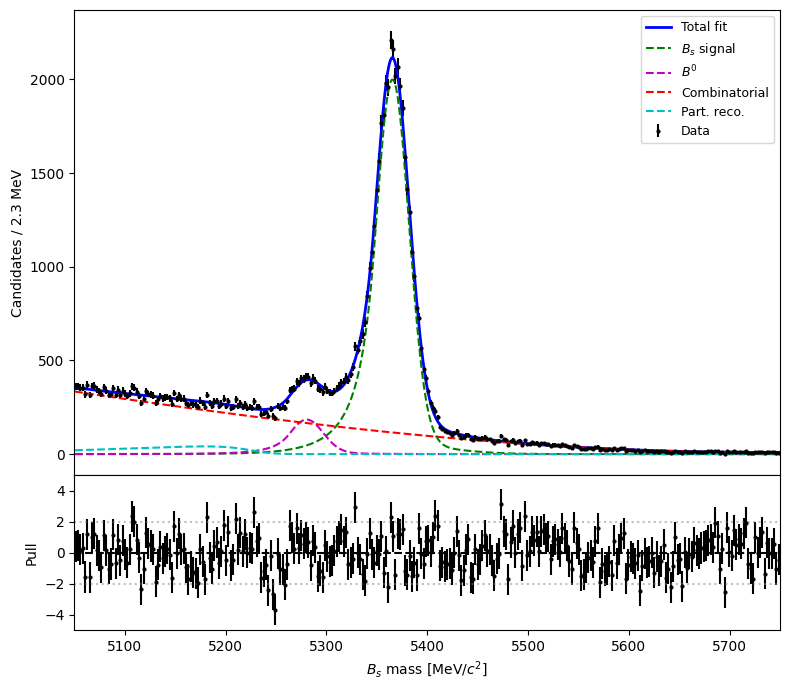

Bs yield:   40377 +/- 513
B0 yield:   3717 +/- 184
Comb yield: 36637 +/- 1482
Part.reco:  2561 +/- 1075
Bs mass:    5365.56 +/- 0.15 MeV
B0 mass:    5280.45 +/- 0.87 MeV
fcb:        0.927 +/- 0.009
sg1:        16.37 +/- 0.15 MeV
sg2:        50.00 +/- 3.63 MeV
beta:       1.132 +/- 0.055
m:          6.03 +/- 2.51
ARGUS m0:   5232.0 (fixed)
ARGUS c:    27.35 +/- 14.25


In [25]:
# --- Plot the data mass fit ---
fig, ax = plt.subplots(2, 1, figsize=(8, 7),
                       gridspec_kw={"height_ratios": (3, 1), "hspace": 0})

ax[0].errorbar(cx, nh, np.sqrt(nh), fmt="k.", markersize=4, label="Data")

xf = np.linspace(mrange[0], mrange[1], 500)
v = mi.values

tot = totcdf(xf, *v)
dx = xf[1] - xf[0]
xm = 0.5 * (xf[1:] + xf[:-1])
ax[0].plot(xm, np.diff(tot)/dx*bw, "b-", linewidth=2, label="Total fit")

sig_c = v["Ns"] * sig_cdf_free(xf, v["mu_s"], v["fcb"], v["sg1"], v["sg2"], v["beta"], v["m"])
ax[0].plot(xm, np.diff(sig_c)/dx*bw, "g--", label=r"$B_s$ signal")

b0_c = v["N0"] * sig_cdf_free(xf, v["mu_0"], v["fcb"], v["sg1"], v["sg2"], v["beta"], v["m"])
ax[0].plot(xm, np.diff(b0_c)/dx*bw, "m--", label=r"$B^0$")

comb_c = v["Nb"] * bkg_cdf_bern(xf, v["b0"], v["b1"], v["b2"], v["b3"])
ax[0].plot(xm, np.diff(comb_c)/dx*bw, "r--", label="Combinatorial")

x_ag, cdf_ag = make_argus_conv_gauss(v["sg1"], v["c_argus"], v["m0_argus"])
pr_c = v["Np"] * np.interp(xf, x_ag, cdf_ag)
ax[0].plot(xm, np.diff(pr_c)/dx*bw, "c--", label="Part. reco.")

ax[0].set_ylabel(f"Candidates / {bw:.1f} MeV")
ax[0].legend(fontsize=9)
ax[0].set_xlim(mrange)
ax[0].tick_params(labelbottom=False)

expected = np.diff(totcdf(xe, *v))
pull = (nh - expected) / np.sqrt(np.maximum(expected, 1))
ax[1].errorbar(cx, pull, 1, fmt="k.", markersize=4)
ax[1].axhline(0, color="k", linestyle="--")
ax[1].axhline(2, color="grey", linestyle=":", alpha=0.5)
ax[1].axhline(-2, color="grey", linestyle=":", alpha=0.5)
ax[1].set_xlabel("$B_s$ mass [MeV/$c^2$]")
ax[1].set_ylabel("Pull")
ax[1].set_ylim(-5, 5)
ax[1].set_xlim(mrange)

plt.tight_layout()
plt.show()

print(f"Bs yield:   {v['Ns']:.0f} +/- {mi.errors['Ns']:.0f}")
print(f"B0 yield:   {v['N0']:.0f} +/- {mi.errors['N0']:.0f}")
print(f"Comb yield: {v['Nb']:.0f} +/- {mi.errors['Nb']:.0f}")
print(f"Part.reco:  {v['Np']:.0f} +/- {mi.errors['Np']:.0f}")
print(f"Bs mass:    {v['mu_s']:.2f} +/- {mi.errors['mu_s']:.2f} MeV")
print(f"B0 mass:    {v['mu_0']:.2f} +/- {mi.errors['mu_0']:.2f} MeV")
print(f"fcb:        {v['fcb']:.3f} +/- {mi.errors['fcb']:.3f}")
print(f"sg1:        {v['sg1']:.2f} +/- {mi.errors['sg1']:.2f} MeV")
print(f"sg2:        {v['sg2']:.2f} +/- {mi.errors['sg2']:.2f} MeV")
print(f"beta:       {v['beta']:.3f} +/- {mi.errors['beta']:.3f}")
print(f"m:          {v['m']:.2f} +/- {mi.errors['m']:.2f}")
print(f"ARGUS m0:   {v['m0_argus']:.1f} (fixed)")
print(f"ARGUS c:    {v['c_argus']:.2f} +/- {mi.errors['c_argus']:.2f}")

### Projection of Signal in Intermediate Masses

In [26]:
# --- sWeights from mass fit ---

v = mi.values

# Signal PDF (CB + Gauss, normalised)
def spdf(x):
    sg1, sg2 = v["sg1"], v["sg2"]
    fcb, beta, m = v["fcb"], v["beta"], v["m"]
    mu = v["mu_s"]
    cb_pdf = crystalball.pdf(x, beta, m, mu, sg1)
    gs_pdf = truncnorm.pdf(x, mrange[0], mrange[1], mu, sg2)
    # Normalise CB to mrange
    cb_norm = np.diff(crystalball.cdf(np.array(mrange), beta, m, mu, sg1))
    cb_pdf_norm = cb_pdf / cb_norm
    return fcb * cb_pdf_norm + (1 - fcb) * gs_pdf

# Background PDF (B0 + Combinatorial + Part.reco, combined & normalised)
def bpdf(x):
    mu_0 = v["mu_0"]
    sg1, sg2 = v["sg1"], v["sg2"]
    fcb, beta, m = v["fcb"], v["beta"], v["m"]
    N0, Nb, Np = v["N0"], v["Nb"], v["Np"]
    Ntot_bkg = N0 + Nb + Np
    
    # B0
    cb_pdf_0 = crystalball.pdf(x, beta, m, mu_0, sg1)
    cb_norm_0 = np.diff(crystalball.cdf(np.array(mrange), beta, m, mu_0, sg1))
    gs_pdf_0 = truncnorm.pdf(x, mrange[0], mrange[1], mu_0, sg2)
    f_b0 = fcb * cb_pdf_0 / cb_norm_0 + (1 - fcb) * gs_pdf_0
    
    # Combinatorial (Bernstein density)
    beta_coeffs = np.array([v["b0"], v["b1"], v["b2"], v["b3"]], dtype=np.float64)
    f_comb = bernstein.density(np.asarray(x, dtype=np.float64), beta_coeffs,
                               np.float64(mrange[0]), np.float64(mrange[1]))
    bern_norm = np.diff(bernstein.integral(np.array(mrange, dtype=np.float64), beta_coeffs,
                                           np.float64(mrange[0]), np.float64(mrange[1])))
    f_comb = f_comb / bern_norm
    
    # Part.reco (ARGUS conv Gauss PDF from numerical derivative of CDF)
    x_ag, cdf_ag = make_argus_conv_gauss(v["sg1"], v["c_argus"], 5232.)
    dx_ag = x_ag[1] - x_ag[0]
    pdf_ag = np.gradient(cdf_ag, dx_ag)
    pdf_ag = np.maximum(pdf_ag, 0)
    f_part = np.interp(x, x_ag, pdf_ag)
    
    return (N0 * f_b0 + Nb * f_comb + Np * f_part) / Ntot_bkg

# Compute sWeights
sw_mass = final_mass
Ns_fit = v["Ns"]
Nb_fit = v["N0"] + v["Nb"] + v["Np"]

sweighter = SWeight(sw_mass, pdfs=[spdf, bpdf], yields=[Ns_fit, Nb_fit],
                    discvarranges=(mrange,), checks=False, verbose=False)

final_df["sw"] = sweighter.get_weight(0, final_mass)
print(f"sWeights computed: sum = {final_df['sw'].sum():.1f} (expect ~{Ns_fit:.0f})")
print(f"  min = {final_df['sw'].min():.2f}, max = {final_df['sw'].max():.2f}")

C:\Users\Ziyao Xiong\AppData\Local\Temp\ipykernel_25040\1641041735.py:32: RuntimeWarning: invalid value encountered in sqrt
  x_ext * np.sqrt(u) * np.exp(-c_argus * u), 0)


sWeights computed: sum = 40376.5 (expect ~40377)
  min = -0.20, max = 1.13


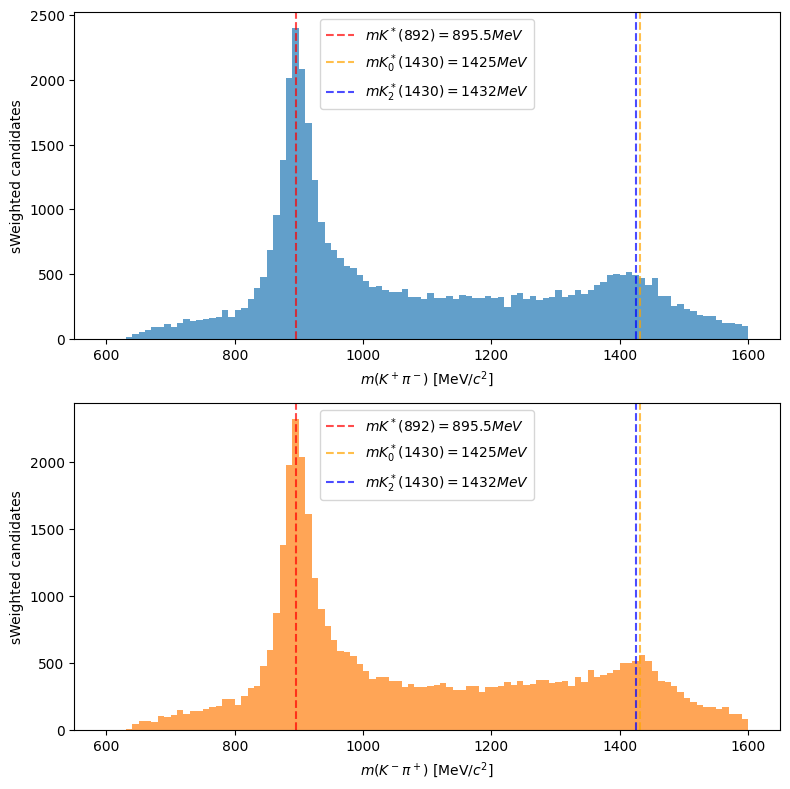

In [27]:
# --- Intermediate mass distributions with sWeights ---
import vector

K_mass  = 493.677
pi_mass = 139.570

def make_p4(df, prefix, mass):
    return vector.arr({
        "px": df[f"{prefix}_PX"].values,
        "py": df[f"{prefix}_PY"].values,
        "pz": df[f"{prefix}_PZ"].values,
        "mass": np.full(len(df), mass)
    })

Kp_4  = make_p4(final_df, "Kp",  K_mass)
pim_4 = make_p4(final_df, "pim", pi_mass)
Km_4  = make_p4(final_df, "Km",  K_mass)
pip_4 = make_p4(final_df, "pip", pi_mass)

mKpim = (Kp_4 + pim_4).m
mKmpip = (Km_4 + pip_4).m
sw = final_df["sw"].values

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

axes[0].hist(mKpim, bins=100, range=(600, 1600), weights=sw,
             color="C0", alpha=0.7)
axes[0].set_xlabel(r"$m(K^+\pi^-)$ [MeV/$c^2$]")
axes[0].set_ylabel("sWeighted candidates")
axes[0].axvline(895.5, color="r", linestyle="--", alpha=0.7, label=r"$mK^*(892)=895.5MeV$")
axes[0].axvline(1432, color="orange", linestyle="--", alpha=0.7, label=r"$mK^*_0(1430)=1425MeV$")
axes[0].axvline(1425, color="blue", linestyle="--", alpha=0.7, label=r"$mK^*_2(1430)=1432MeV$")
axes[0].legend()

axes[1].hist(mKmpip, bins=100, range=(600, 1600), weights=sw,
             color="C1", alpha=0.7)
axes[1].set_xlabel(r"$m(K^-\pi^+)$ [MeV/$c^2$]")
axes[1].set_ylabel("sWeighted candidates")
axes[1].axvline(895.5, color="r", linestyle="--", alpha=0.7, label=r"$mK^*(892)=895.5MeV$")
axes[1].axvline(1432, color="orange", linestyle="--", alpha=0.7, label=r"$mK^*_0(1430)=1425MeV$")
axes[1].axvline(1425, color="blue", linestyle="--", alpha=0.7, label=r"$mK^*_2(1430)=1432MeV$")

axes[1].legend()

plt.tight_layout()
plt.show()

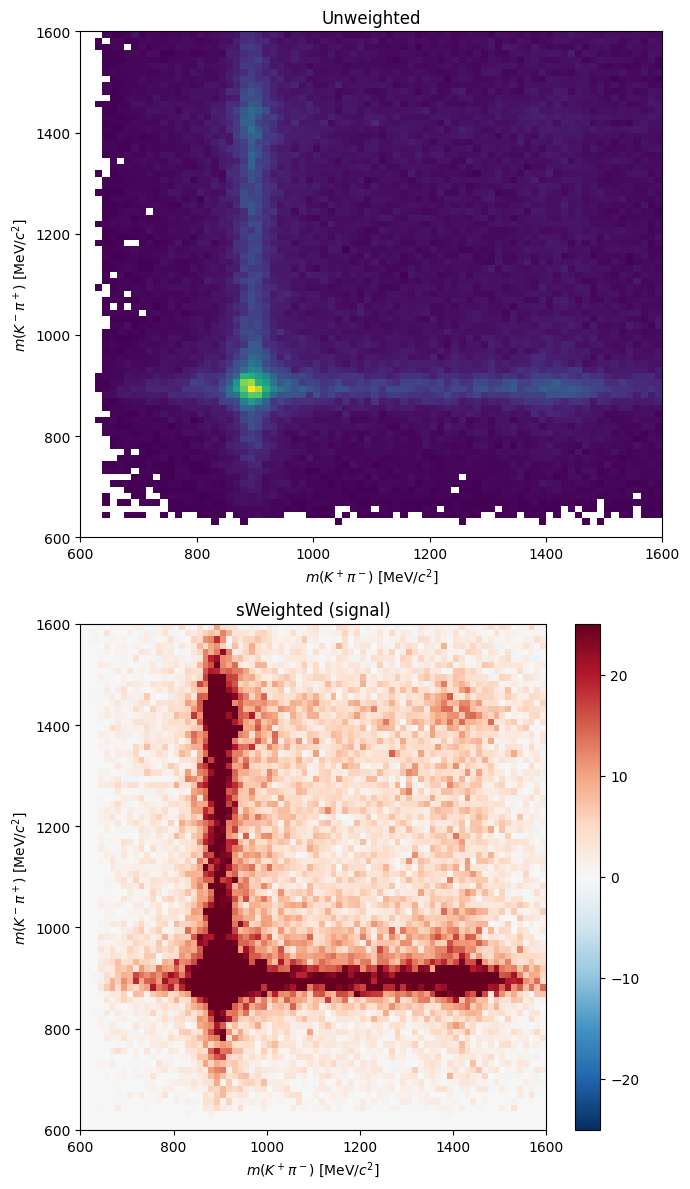

In [28]:
# --- Dalitz plot: sWeighted ---
fig, axes = plt.subplots(2, 1, figsize=(7, 12))

# Unweighted
axes[0].hist2d(mKpim, mKmpip, bins=80,
               range=[[600, 1600], [600, 1600]], cmin=1)
axes[0].set_xlabel(r"$m(K^+\pi^-)$ [MeV/$c^2$]")
axes[0].set_ylabel(r"$m(K^-\pi^+)$ [MeV/$c^2$]")
axes[0].set_title("Unweighted")

# sWeighted
h, xe, ye = np.histogram2d(mKpim, mKmpip, bins=80,
                           range=[[600, 1600], [600, 1600]], weights=sw)
mesh = axes[1].pcolormesh(xe, ye, h.T, cmap="RdBu_r",
                          vmin=-np.percentile(np.abs(h), 95),
                          vmax=np.percentile(np.abs(h), 95))
axes[1].set_xlabel(r"$m(K^+\pi^-)$ [MeV/$c^2$]")
axes[1].set_ylabel(r"$m(K^-\pi^+)$ [MeV/$c^2$]")
axes[1].set_title("sWeighted (signal)")
fig.colorbar(mesh, ax=axes[1])

plt.tight_layout()
plt.show()

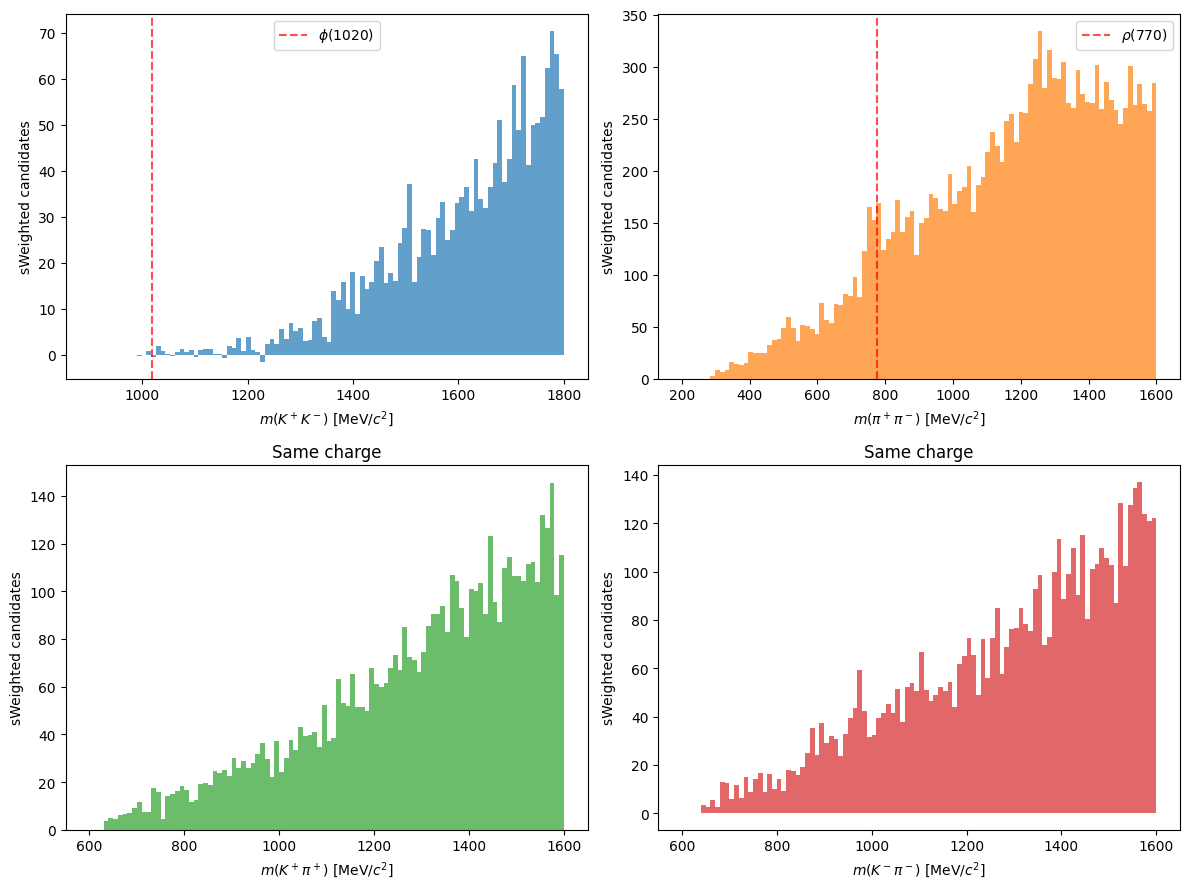

In [29]:
# --- Other 2-body mass spectra (sWeighted) ---
mKK   = (Kp_4 + Km_4).m
mpipi = (pip_4 + pim_4).m
mKppip = (Kp_4 + pip_4).m   # same charge
mKmpim = (Km_4 + pim_4).m   # same charge

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].hist(mKK, bins=100, range=(900, 1800), weights=sw, color="C0", alpha=0.7)
axes[0,0].axvline(1019.5, color="r", linestyle="--", alpha=0.7, label=r"$\phi(1020)$")
axes[0,0].set_xlabel(r"$m(K^+K^-)$ [MeV/$c^2$]")
axes[0,0].set_ylabel("sWeighted candidates")
axes[0,0].legend()

axes[0,1].hist(mpipi, bins=100, range=(200, 1600), weights=sw, color="C1", alpha=0.7)
axes[0,1].axvline(775, color="r", linestyle="--", alpha=0.7, label=r"$\rho(770)$")
axes[0,1].set_xlabel(r"$m(\pi^+\pi^-)$ [MeV/$c^2$]")
axes[0,1].set_ylabel("sWeighted candidates")
axes[0,1].legend()

axes[1,0].hist(mKppip, bins=100, range=(600, 1600), weights=sw, color="C2", alpha=0.7)
axes[1,0].set_xlabel(r"$m(K^+\pi^+)$ [MeV/$c^2$]")
axes[1,0].set_ylabel("sWeighted candidates")
axes[1,0].set_title("Same charge")

axes[1,1].hist(mKmpim, bins=100, range=(600, 1600), weights=sw, color="C3", alpha=0.7)
axes[1,1].set_xlabel(r"$m(K^-\pi^-)$ [MeV/$c^2$]")
axes[1,1].set_ylabel("sWeighted candidates")
axes[1,1].set_title("Same charge")

plt.tight_layout()
plt.show()

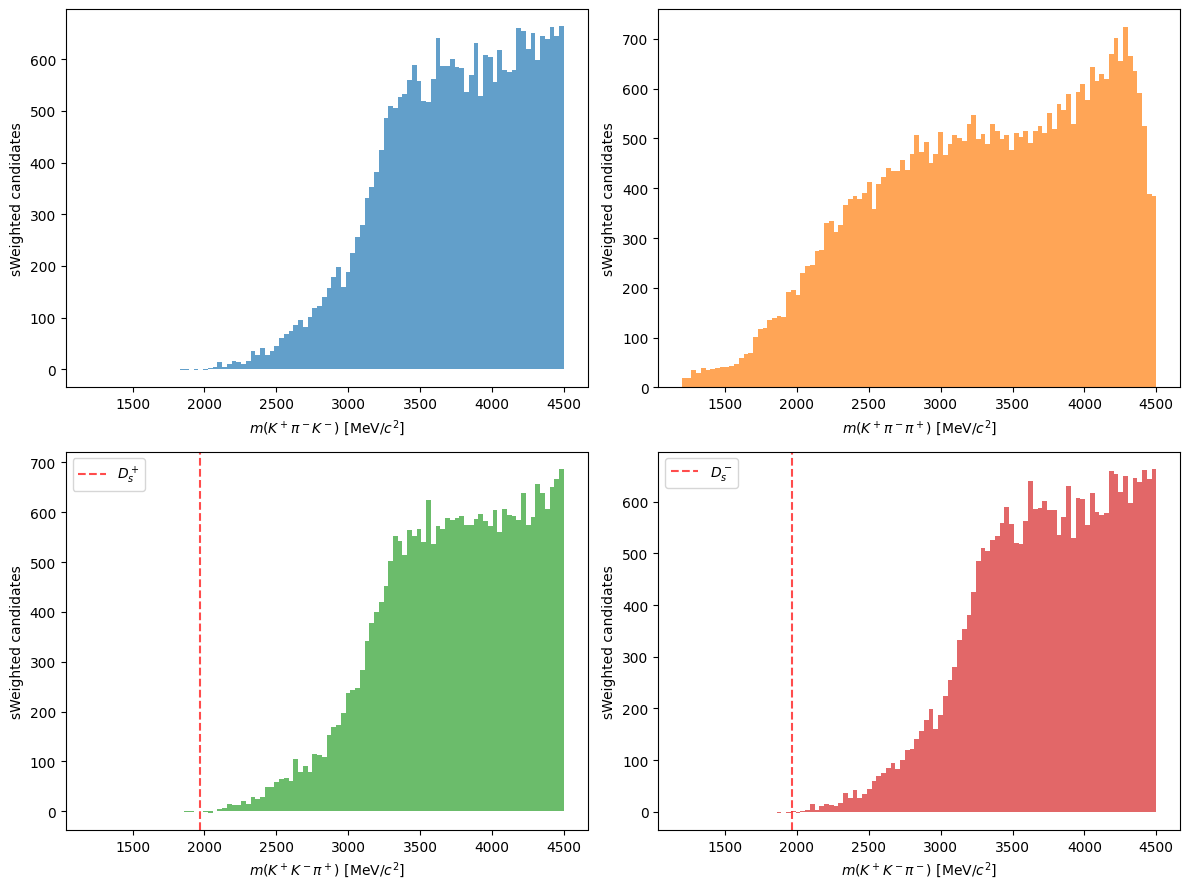

In [30]:
# --- 3-body mass spectra (sWeighted) ---
mKpimKm  = (Kp_4 + pim_4 + Km_4).m
mKpimpip = (Kp_4 + pim_4 + pip_4).m
mKKpip   = (Kp_4 + Km_4 + pip_4).m
mKKpim   = (Kp_4 + Km_4 + pim_4).m

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].hist(mKpimKm, bins=100, range=(1200, 4500), weights=sw, color="C0", alpha=0.7)
axes[0,0].set_xlabel(r"$m(K^+\pi^-K^-)$ [MeV/$c^2$]")
axes[0,0].set_ylabel("sWeighted candidates")

axes[0,1].hist(mKpimpip, bins=100, range=(1200, 4500), weights=sw, color="C1", alpha=0.7)
axes[0,1].set_xlabel(r"$m(K^+\pi^-\pi^+)$ [MeV/$c^2$]")
axes[0,1].set_ylabel("sWeighted candidates")

axes[1,0].hist(mKKpip, bins=100, range=(1200, 4500), weights=sw, color="C2", alpha=0.7)
axes[1,0].axvline(1968, color="r", linestyle="--", alpha=0.7, label=r"$D_s^+$")
axes[1,0].set_xlabel(r"$m(K^+K^-\pi^+)$ [MeV/$c^2$]")
axes[1,0].set_ylabel("sWeighted candidates")
axes[1,0].legend()

axes[1,1].hist(mKKpim, bins=100, range=(1200, 4500), weights=sw, color="C3", alpha=0.7)
axes[1,1].axvline(1968, color="r", linestyle="--", alpha=0.7, label=r"$D_s^-$")
axes[1,1].set_xlabel(r"$m(K^+K^-\pi^-)$ [MeV/$c^2$]")
axes[1,1].set_ylabel("sWeighted candidates")
axes[1,1].legend()

plt.tight_layout()
plt.show()